In [3]:
import numpy as np
import matplotlib.pyplot as plt
import os
import re

In [4]:
out_dir_M = "NSL_SIMULATOR/OUTPUT/METROPOLIS/"
out_dir_G = "NSL_SIMULATOR/OUTPUT/GIBBS/"
out_dir_eq_M = "NSL_SIMULATOR/OUTPUT/EQUILIBRATION/METROPOLIS/"
out_dir_eq_G = "NSL_SIMULATOR/OUTPUT/EQUILIBRATION/GIBBS/"

In [31]:
# ========================
# Reading data function
# ========================

def load_file(filepath):
    data = []
    with open(filepath, 'r') as f:
        for line in f:
            if line.strip().startswith('#') or not line.strip():
                continue
            # If a number is attached to the minus signed of the next one, this adds a space in the middle
            fixed_line = re.sub(r'(\d)(\-)', r'\1 \2', line)
            data.append([float(x) for x in fixed_line.split()])
    return np.array(data)

# ========================================================================
# Helper function to avoid repeating try...except blocks in plotting
# ========================================================================
def append_data(prefix, t_string, sim_list, err_list):
    try:
        data = load_file(os.path.join(out_dir_M, f"{prefix}_{t_string}.dat"))
        sim_list.append(data[-1, 2])
        err_list.append(data[-1, 3])
    except OSError:
        pass

# The 1D Ising Model

## Theory

The aim of this exercise is to use two different sampling techniques (Metropolis and Gibbs algorithms) to study the evolution with temperature of quantities related to a spin chain of $N_s= 50$ spins described by a 1D Ising Model. The 1D Ising Model is exactly solvable, i.e., the partition function can be factorized and the sum can be written in closed form. This allows for a direct comparison between Monte Carlo simulations and analytical results.

Assuming units such that $\mu_B=1$ and $k_B=1$, the Hamiltonian of the 1D Ising Model is:
$$H = -J\sum_{i=1}^{N_s} s_i s_{i+1} -h\sum_{i=1}^{N_s} s_i $$
where $J$ is the interaction constant and $h$ is the external magnetic field. Spins $\{ s_i \}_{i=1,N_s}$ take values in $\{-1, 1\}$. By assuming periodic boundary conditions (equivalent to a ring of spins), i.e., $s_{N_s+1} = s_{1}$, we ensure that all spins have the same number of nearest neighbors (in 1D there are 2 nearest neighbors), thus avoiding boundary effects.

The sign of $J$ determines whether the system is ferromagnetic ($J > 0$: configurations with aligned spins are favored) or antiferromagnetic ($J < 0$: configurations with anti-aligned spins are favored). From now on, we will assume $J = 1$.  

The partition function is:
$$Z=\sum_{\{ s_i \}} \exp \left( -\beta H\right) = \lambda_1^{N_s} + \lambda_2^{N_s}$$
where $\lambda_{1,2} = e^{\beta J} \cosh (\beta h) \pm \left[ e^{2\beta J} \cosh^2 (\beta h) - 2\sinh (2\beta J) \right]^{1/2}$, and $\beta= \frac{1}{T}$. 

In the canonical ensemble, once the partition function is known, any thermodynamical quantity can be exactly calculated from it and its derivatives. The quantities of interest in this notebook are the **internal energy**, **heat capacity**, **susceptibility** (simulated for $h=0$), and **magnetization** (simulated for $h=0.02$) as functions of temperature in the range $T \in [0.5, 2.0]$.

The magnetization is not calculated in the absence of an external field because the 1D Ising Model does not show spontaneous magnetization at finite temperature; therefore, if $h=0$, the mean magnetization would be zero at any temperature. With a small external field, states with spins aligned with the field are favored, causing the spins to align with one another along the direction of the external field at low temperatures.

In the canonical ensemble, the system is described by the Helmholtz free energy:
$$A(N,V,T) = U - TS$$
where $U$ is the internal energy and $S$ is the entropy. The equilibrium configuration is reached by minimizing the Helmholtz free energy. When the temperature is high, the entropic term dominates over the energy term, leading the system to exhibit more random spin configurations. Equivalently, at high temperatures, the thermal energy is sufficient to flip spins into configurations that are not energetically favored. At low temperatures, the energy term starts to dominate, and more ordered spin configurations emerge at equilibrium.

## Computational challenges

This physical behavior introduces a significant computational challenge, rooted in the **local nature of our update algorithms**. Both the Metropolis and Gibbs algorithms sample the phase space by updating *one single spin at a time*. 

At low temperatures, the system naturally settles into highly ordered configurations (large domains of aligned spins). Attempting to flip a single spin against an ordered domain carries a high energy penalty ($\Delta E = 4J$). As a result, both algorithms become highly inefficient, albeit in different ways:
- In the **Metropolis algorithm**, the acceptance probability for such moves plummets, dropping the overall acceptance rate from $\sim 50\%$ at $T=2.0$ to $\sim 2\%$ at $T=0.5$, leading to continuous rejections.
- In the **Gibbs algorithm**, while the update is always accepted by definition, the conditional probability overwhelmingly favors the spin state that aligns with its neighbors. Consequently, the algorithm repeatedly assigns the spin its identical previous value, performing "empty" updates.

In both cases, the system gets trapped in the same microscopic state for a very long Monte Carlo time.

This trapping implies that if the simulation blocks are too short, the system does not have enough time to evolve into configurations that are statistically independent from previous ones. Measuring highly correlated data inevitably produces a severe underestimation of the statistical errors. 

To overcome this issue and obtain uncorrelated block averages in our simulation, we must significantly increase the number of steps within each block. This extended time allows the system to accumulate enough actual state changes to properly decorrelate. Ultimately, to efficiently explore the phase space at low temperatures without requiring massive simulation times, one would need to implement non-local sampling techniques (such as cluster algorithms) that can flip entire domains of spins simultaneously.

At high temperatures ($T=2.0$), the system is practically uncorrelated, and the block averages are statistically independent. However, we can still observe an underestimation of the error in the very first blocks. This is not due to physical correlation, but rather to the inherent statistical instability of the variance estimator when computed with a very small number of samples ($N=2$). If two independent block averages happen to be similar by pure statistical chance, the computed error will drop artificially. This reinforces the necessity of running the simulation for a sufficient number of blocks ($N \approx 40$) to allow the statistical estimators to converge and become reliable, regardless of the system's physical correlation.

## The Metropolis Algorithm for the Ising Model

Unlike simulations of continuous systems (such as the position of an electron in the Hydrogen atom) where variables are updated using continuous proposal distributions (e.g., Uniform or Gaussian steps), the Ising model is characterized by discrete, binary variables: the spins $s_i \in \{-1, 1\}$. 

- **Target Distribution:**
Since we are simulating the system in the canonical ensemble at a fixed temperature $T$, our goal is to sample the phase space such that the probability of visiting a specific microscopic configuration $\mu = \{s_1, \dots, s_N\}$ follows the **Boltzmann distribution** $$p(\mu) = \frac{1}{Z} e^{-\beta E_\mu}$$ where $E_\mu$ is the internal energy of the configuration and $\beta = 1/T$.

- **Proposal Distribution (Single-Spin Flip):**
To explore the phase space, the Metropolis algorithm employs a **single-spin flip** proposal. At each step, a single spin $i$ is chosen uniformly at random among the $N_s$ available spins. The proposed new configuration, $\nu$, is identical to the current one, $\mu$, except that the $i$-th spin is inverted ($s_i \rightarrow -s_i$). 
Because flipping the same spin again would return the system to its exact previous state, this transition probability is perfectly symmetric, meaning $T(\nu|\mu) = T(\mu|\nu)$. 

- **Acceptance Rule:**
Since the proposal probability is symmetric, it cancels out in the Metropolis acceptance ratio. The probability $A(\nu|\mu)$ of accepting the proposed spin flip depends strictly on the Boltzmann weights of the two states, which reduces to the energy difference $\Delta E = E_\nu - E_\mu$: $$A(\nu|\mu) = \min \left[ 1, \frac{p(\nu)}{p(\mu)} \right] = \min \left[ 1, e^{-\beta \Delta E} \right]$$ In practice:
    - If the flip lowers the energy ($\Delta E \le 0$), the move is always accepted.
    - If the flip increases the energy ($\Delta E > 0$), the move is accepted with a probability $e^{-\beta \Delta E}$. A random number $r \in [0, 1)$ is drawn from a uniform distribution, and the flip is accepted only if $r < e^{-\beta \Delta E}$.

## The Gibbs Algorithm for the Ising Model

Gibbs Sampling (also known as Heat-Bath sampling) is a Markov chain Monte Carlo technique where the proposed move is always accepted. Given a multivariate probability distribution, the algorithm updates one variable at a time by replacing its current value with a new one drawn directly from its conditional probability distribution, assuming all other variables in the system are kept temporarily fixed. These base transitions are usually performed sequentially across the lattice.

In the context of the 1D Ising model, this algorithm is mathematically elegant because each spin $s_i$ only has two possible states ($\pm 1$). When updating the $i$-th spin, the algorithm evaluates the conditional probability $p(s_i | \{s_{j \neq i}\})$. Because of the nearest-neighbor nature of the interactions, this probability depends exclusively on the fixed states of the adjacent spins, $s_{i-1}$ and $s_{i+1}$.

To find this probability, we start from the definition of conditional probability in the Boltzmann distribution:
$$p(s_i = +1 | \{s_{j \neq i}\}) = \frac{p(s_i = +1, \{s_{j \neq i}\})}{p(s_i = +1, \{s_{j \neq i}\}) + p(s_i = -1, \{s_{j \neq i}\})}$$

By substituting the joint probabilities with their corresponding Boltzmann weights $p(\mu) \propto e^{-\beta E_\mu}$ (the partition function $Z$ simplifies out), we get:
$$p(s_i = +1 | s_{i-1}, s_{i+1}) = \frac{e^{-\beta E(s_i = +1)}}{e^{-\beta E(s_i = +1)} + e^{-\beta E(s_i = -1)}}$$

By dividing both the numerator and the denominator by $e^{-\beta E(s_i = +1)}$, we obtain:
$$p(s_i = +1 | s_{i-1}, s_{i+1}) = \frac{1}{1 + e^{-\beta [E(s_i = -1) - E(s_i = +1)]}}$$

We can now define the energy difference $\Delta E$ as the energy cost of flipping the spin from DOWN to UP:
$$\Delta E = E(s_i = -1) - E(s_i = +1) = 2 \left[J \cdot (s_{i-1} + s_{i+1}) + h\right]$$

Substituting $\Delta E$ back into our equation, the exact local thermal probability for the spin to be in the UP state becomes the standard logistic function:
$$p(s_i = +1 | s_{i-1}, s_{i+1}) = \frac{1}{1 + e^{-\beta \Delta E}}$$

Instead of calculating an acceptance ratio to decide whether to flip the current spin (as in the Metropolis algorithm), the Gibbs sampler simply computes this exact probability. A random number $r \in [0, 1)$ is then drawn from a uniform distribution. If $r < p(s_i = +1 | s_{i-1}, s_{i+1})$, the spin is set to $+1$; otherwise, it is set to $-1$. Because the new state is drawn directly from the exact local equilibrium distribution, the move is perfectly physical and is therefore always accepted, yielding an acceptance rate of exactly $100\%$.

## Equilibration

The simulation starts from a random configuration, where each spin is oriented up or down with equal probability. This is physically equivalent to starting the system at an infinite temperature ($T \to \infty$). Consequently, before starting to measure any thermodynamic observable, the system must be allowed to relax and reach thermal equilibrium at the target temperature $T$. 

To determine the necessary equilibration time, we perform a preliminary thermalization run. We configure the simulation to output the instantaneous values of the internal energy and magnetization at each Monte Carlo step (achieved by setting the block size to exactly 1 step). By plotting these instantaneous values as a function of the simulation steps, we can observe an initial transient phase where the observables drift rapidly toward their asymptotic values, followed by a "plateau."

It is important to note that, because the system is simulated in the canonical ensemble, the internal energy is not strictly constant but fluctuates due to thermal exchanges with the heat bath. Therefore, the "plateau" does not manifest as a perfectly flat horizontal line, but rather as a regime where the instantaneous values fluctuate stably around a well-defined mean, with no overall macroscopic drift. The step at which this stable fluctuation begins defines our equilibration time, $t_{eq}$. Once $t_{eq}$ is known, we can safely discard the first $t_{eq}$ steps in our actual simulations before starting the Data Blocking averages.

#### Equilibration result

In the following figures, we visualize this process for the "worst-case scenario": a system starting from a completely random spin configuration ($T=\infty$) and equilibrating at the lowest simulated temperature, $T=0.5$. We plot the instantaneous magnetization and internal energy for both the Metropolis and Gibbs algorithms. As the plots demonstrate, the thermal quench is extremely rapid; despite the low temperature, the system drops into the stable fluctuation regime (the plateau) in just a few dozen Monte Carlo steps.

At $T=0.5$, the thermal energy is incredibly low compared to the interaction penalty. The system spends the vast majority of its Monte Carlo time frozen in the perfect ground state. The sharp "spikes" we observe represent rare thermal fluctuations (a single spin flipping against the local domain) which are almost immediately reverted in the subsequent steps due to the high energy cost. 

The equilibration is performed setting `NBLOCKS = 500`, `NSTEPS = 1`, `RESTART = 0` and `TEMP = 0.5` in `input.dat`. The initial configuration is copied from `config.ising` into `config.spin` to start from a totally random configuration.

The simulation is run and the resulting equilibration time is the absolute worst case scenario, that will be applied throughout the whole successive simulations to ensure a equilibrated system.

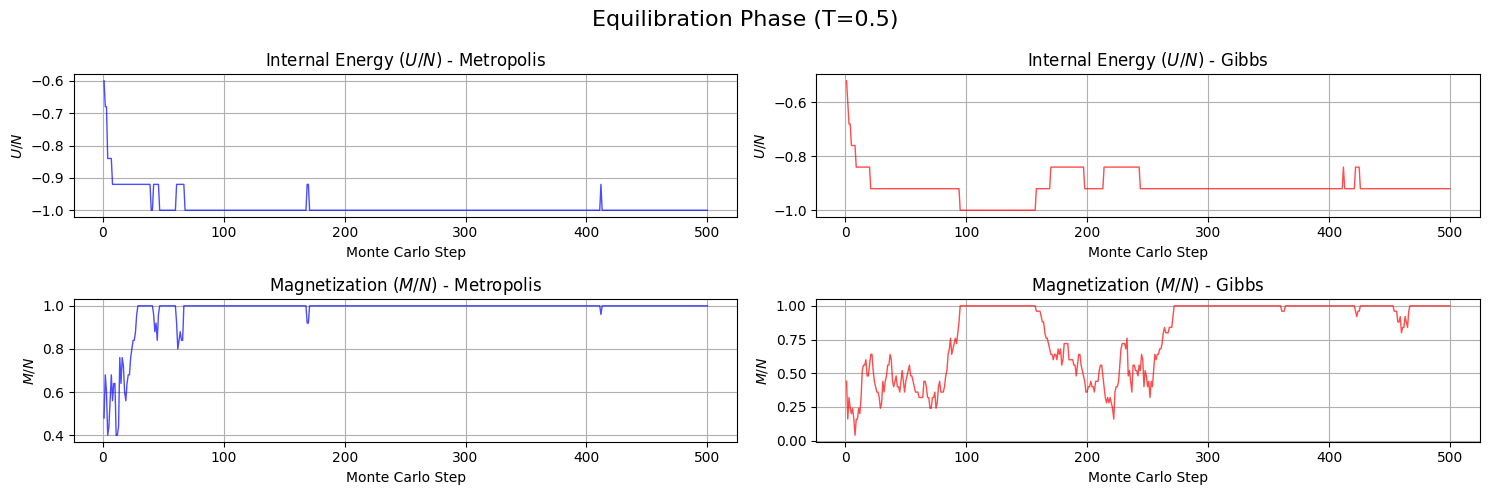

In [6]:
# ============================================================
# Plot internal energy and magnetization for equilibration
# ============================================================

# Load
step, energy_M, _, _ = load_file(out_dir_eq_M + "total_energy_0_50.dat").T
step, magnetization_M, _, _ = load_file(out_dir_eq_M + "magnetization_0_50.dat").T
step, energy_G, _, _ = load_file(out_dir_eq_G + "total_energy_0_50.dat").T
step, magnetization_G, _, _ = load_file(out_dir_eq_G + "magnetization_0_50.dat").T

# Plot
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 5))
fig.suptitle('Equilibration Phase (T=0.5)', fontsize=16)

# == Internal energy
ax1.plot(step, energy_M, color='blue', alpha=0.7, linewidth=1)
ax1.set_title('Internal Energy ($U/N$) - Metropolis')
ax1.set_xlabel('Monte Carlo Step')
ax1.set_ylabel('$U/N$')
ax1.grid(True)

ax2.plot(step, energy_G, color='red', alpha=0.7, linewidth=1)
ax2.set_title('Internal Energy ($U/N$) - Gibbs')
ax2.set_xlabel('Monte Carlo Step')
ax2.set_ylabel('$U/N$')
ax2.grid(True)

# == Magnetization
ax3.plot(step, magnetization_M, color='blue', alpha=0.7, linewidth=1)
ax3.set_title('Magnetization ($M/N$) - Metropolis')
ax3.set_xlabel('Monte Carlo Step')
ax3.set_ylabel('$M/N$')
ax3.grid(True)

ax4.plot(step, magnetization_G, color='red', alpha=0.7, linewidth=1)
ax4.set_title('Magnetization ($M/N$) - Gibbs')
ax4.set_xlabel('Monte Carlo Step')
ax4.set_ylabel('$M/N$')
ax4.grid(True)

plt.tight_layout()
plt.show()

This visual evidence perfectly highlights the physical trapping effect discussed earlier: at low temperatures, successive Monte Carlo steps are almost identical. It visually reinforces why grouping hundreds of thousands of these highly correlated instantaneous measurements into a single "block" is absolutely mandatory to extract meaningful, independent statistical averages and uncertainties.

As these plots demonstrate, the system is already well-equilibrated after approximately 500 steps (equivalent to 500 single-spin trial flips). It is worth noting that this represents the absolute worst-case scenario. 

Conversely, when the equilibration is performed starting from a completely random distribution towards a higher equilibrium temperature of $T = 2.0$, the initial transient phase is virtually imperceptible. The following plots illustrate this immediate thermalization process at $T = 2.0$, where the system instantly exhibits stable thermal fluctuations without any macroscopic drift.

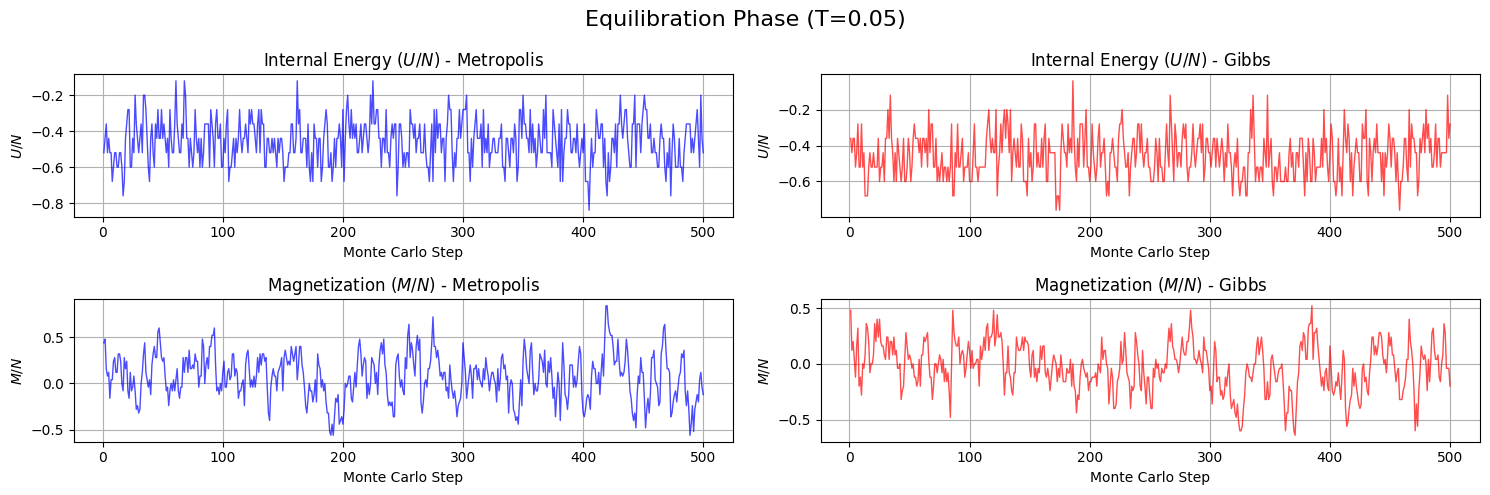

In [7]:
# ============================================================
# Plot internal energy and magnetization for equilibration
# ============================================================

# Load
step , energy_M, _, _ = load_file(out_dir_eq_M + "total_energy_2_00.dat").T
step, magnetization_M, _, _ = load_file(out_dir_eq_M + "magnetization_2_00.dat").T
step, energy_G, _, _ = load_file(out_dir_eq_G + "total_energy_2_00.dat").T
step, magnetization_G, _, _ = load_file(out_dir_eq_G + "magnetization_2_00.dat").T

# Plot
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 5))
fig.suptitle('Equilibration Phase (T=0.05)', fontsize=16)

# == Internal energy
ax1.plot(step, energy_M, color='blue', alpha=0.7, linewidth=1)
ax1.set_title('Internal Energy ($U/N$) - Metropolis')
ax1.set_xlabel('Monte Carlo Step')
ax1.set_ylabel('$U/N$')
ax1.grid(True)

ax2.plot(step, energy_G, color='red', alpha=0.7, linewidth=1)
ax2.set_title('Internal Energy ($U/N$) - Gibbs')
ax2.set_xlabel('Monte Carlo Step')
ax2.set_ylabel('$U/N$')
ax2.grid(True)

# == Magnetization
ax3.plot(step, magnetization_M, color='blue', alpha=0.7, linewidth=1)
ax3.set_title('Magnetization ($M/N$) - Metropolis')
ax3.set_xlabel('Monte Carlo Step')
ax3.set_ylabel('$M/N$')
ax3.grid(True)

ax4.plot(step, magnetization_G, color='red', alpha=0.7, linewidth=1)
ax4.set_title('Magnetization ($M/N$) - Gibbs')
ax4.set_xlabel('Monte Carlo Step')
ax4.set_ylabel('$M/N$')
ax4.grid(True)

plt.tight_layout()
plt.show()

## Theoretical curves

In the following cells is the definition of the theoretical curves that will be compared with the simulated data.

In [8]:
# ==========================================
# Theoretical curves
# ==========================================

# Parameters
J = 1.0
Ns = 50
h = 0.02 # external field for magnetization

# Internal energy
def U(T):
    beta = 1/T
    return -J * np.tanh(beta * J) * (1 + np.tanh(beta * J)**(Ns-2)) / (1 + np.tanh(beta * J)**Ns)

# Suseptivity
def chi(T):
    beta = 1/T
    return beta * np.exp(2* beta *J) * (1 - np.tanh(J/T)**Ns)/(1 + np.tanh(J/T)**Ns)

# Magnetization
def M(T, h):
    beta = 1/T
    l1 = np.exp(beta*J)*np.cosh(beta*h) + np.sqrt(np.exp(2*beta*J)*np.cosh(beta*h)**2 - 2*np.sinh(2*beta*J))
    l2 = np.exp(beta*J)*np.cosh(beta*h) - np.sqrt(np.exp(2*beta*J)*np.cosh(beta*h)**2 - 2*np.sinh(2*beta*J))
    Z = l1**Ns + l2**Ns
    term1 = (l1**(Ns-1)) * (1 + np.exp(beta*J)*np.cosh(beta*h)/np.sqrt(np.exp(2*beta*J)*np.cosh(beta*h)**2 - 2*np.sinh(2*beta*J)))
    term2 = (l2**(Ns-1)) * (1 - np.exp(beta*J)*np.cosh(beta*h)/np.sqrt(np.exp(2*beta*J)*np.cosh(beta*h)**2 - 2*np.sinh(2*beta*J)))
    return (np.exp(beta*J)*np.sinh(beta*h) * (term1 + term2)) / Z

# Specific heat
def cv(T):
    beta = 1/T
    
    num1 = 1 + np.tanh(beta*J)**Ns + (Ns-1)*np.tanh(beta*J)**2 + (Ns-1)*np.tanh(beta*J)**(Ns-2)
    term1 = num1 / (1 + np.tanh(beta*J)**Ns)

    num2 = np.tanh(beta*J) + np.tanh(beta*J)**(Ns-1)
    term2 = Ns * (num2 / (1 + np.tanh(beta*J)**Ns))**2

    return (beta * J)**2 * (term1 - term2)
    

### Simulation Strategy and Python Pipeline

Since Markov Chain Monte Carlo algorithms produce sequences of highly correlated microscopic configurations, we employ the Data Blocking technique. To ensure statistical independence between block averages, the simulation must be performed using sufficiently large blocks. For our production runs, we set `NBLOCKS = 100` and `NSTEPS = 20000`. The simulation type is set to `2` for the Metropolis algorithm (and subsequently `3` for the Gibbs sampler).

To efficiently collect data across the entire temperature range, the simulations are orchestrated by a custom Python script (`pipeline.py`). This script automates the *Simulated Cooling* protocol: after automatically initializing the first run at the highest temperature from a random configuration, it sequentially lowers the temperature, manages the `RESTART` conditions, and copies the final spin configuration of the previous run to be used as the starting point for the next one. This strategy ensures that the system is always exceptionally close to equilibrium at the beginning of each new temperature step, keeping the required equilibration time minimal and consistent across all simulations.

#### Pipeline Execution Instructions

The Python pipeline is designed to run in two distinct modes, depending on the thermodynamic properties being measured:

*   **The `whole` mode (Zero External Field):**
    To measure internal energy, specific heat, and susceptibility, the system must be simulated with no external magnetic field.
    *   **Setup:** In `input.dat`, set the correct simulation type (e.g., `2` for Metropolis) with parameters J = 1.0 and h = 0.0. In `properties.dat`, ensure that only `TOTAL_ENERGY`, `SPECIFIC_HEAT`, and `SUSCEPTIBILITY` are enabled.
    *   **Execution:** While you are in directory `Lab06`, run the command `python pipeline.py whole`. The script will automatically configure the initial run for T = 2.0 with `RESTART 0`, execute it, and then automatically handle the progressive cooling down to T = 0.5, setting `RESTART 1` for all subsequent steps.

*   **The `magnetization` mode (Non-Zero External Field):**
    Because the theoretical magnetization of the Ising model is strictly zero without an external field, a small field must be applied to observe this property.
    *   **Setup:** Before launching the script, manually edit `input.dat` to set the external magnetic field to h = 0.02. In `properties.dat`, enable only the `MAGNETIZATION` property.
    *   **Execution:** Run the command `python pipeline.py magnetization`. Similar to the other mode, the script automatically initializes the first run at T = 2.0 from a random configuration (`RESTART 0`) before managing the simulated cooling process and properly formatting the resulting output files for the magnetization data.

#### Data Management and Storage Optimization

To keep the project repository lightweight and optimize storage, the pipeline includes an automatic data-shrinking feature. For the majority of the simulated temperatures, the script automatically reduces the final `.dat` files by retaining only the header and the final block average (the 100th block containing the ultimate global estimation and its error). The full, uncompressed history of the data blocking procedure (all 100 blocks) is preserved intact strictly for three key temperatures: $T = 2.0$, $T = 1.0$, and $T = 0.5$. This allows for detailed statistical analysis and visualization of the data blocking convergence within this notebook, without cluttering the repository with unnecessary intermediate data.

# Results: Metropolis

## Comparison with theoretical curves

The results of the simulation show very good agreement with the theoretical curves. Wanting to highlight the error bars, I also reported the difference between the theoretical curve and the data points. The plots show random fluctuations around the theoretical value, with smaller uncertainties at higher temperatures.

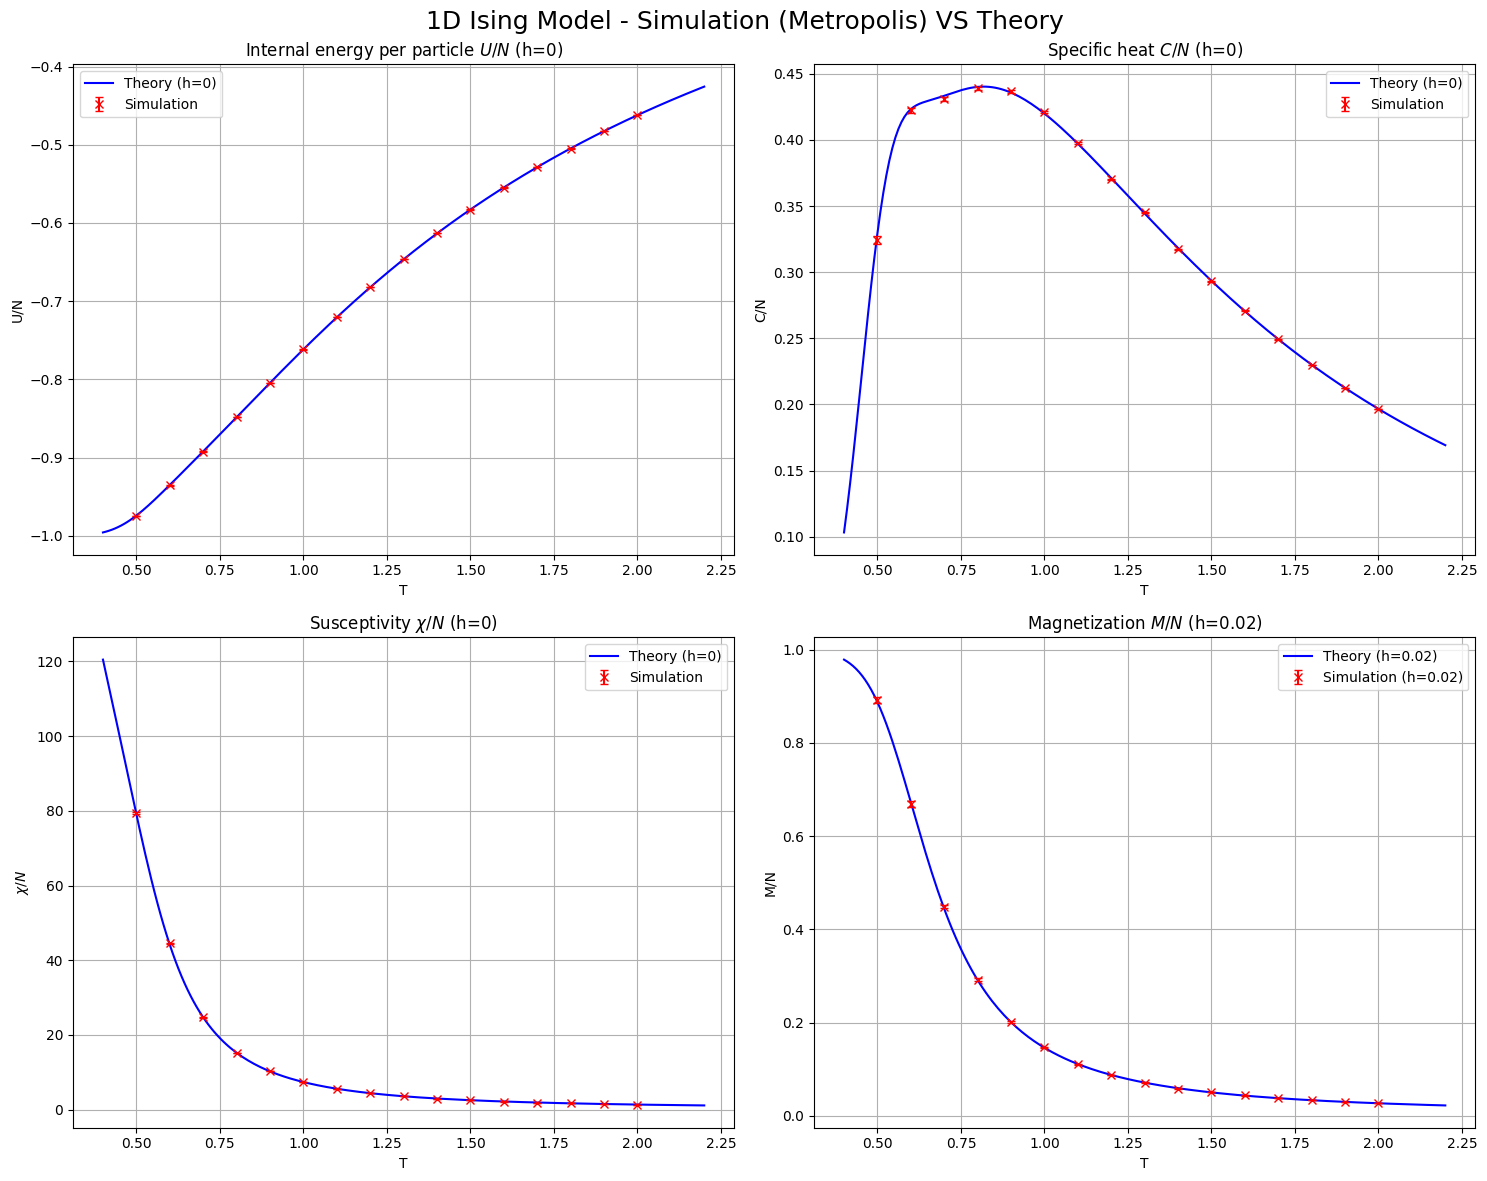

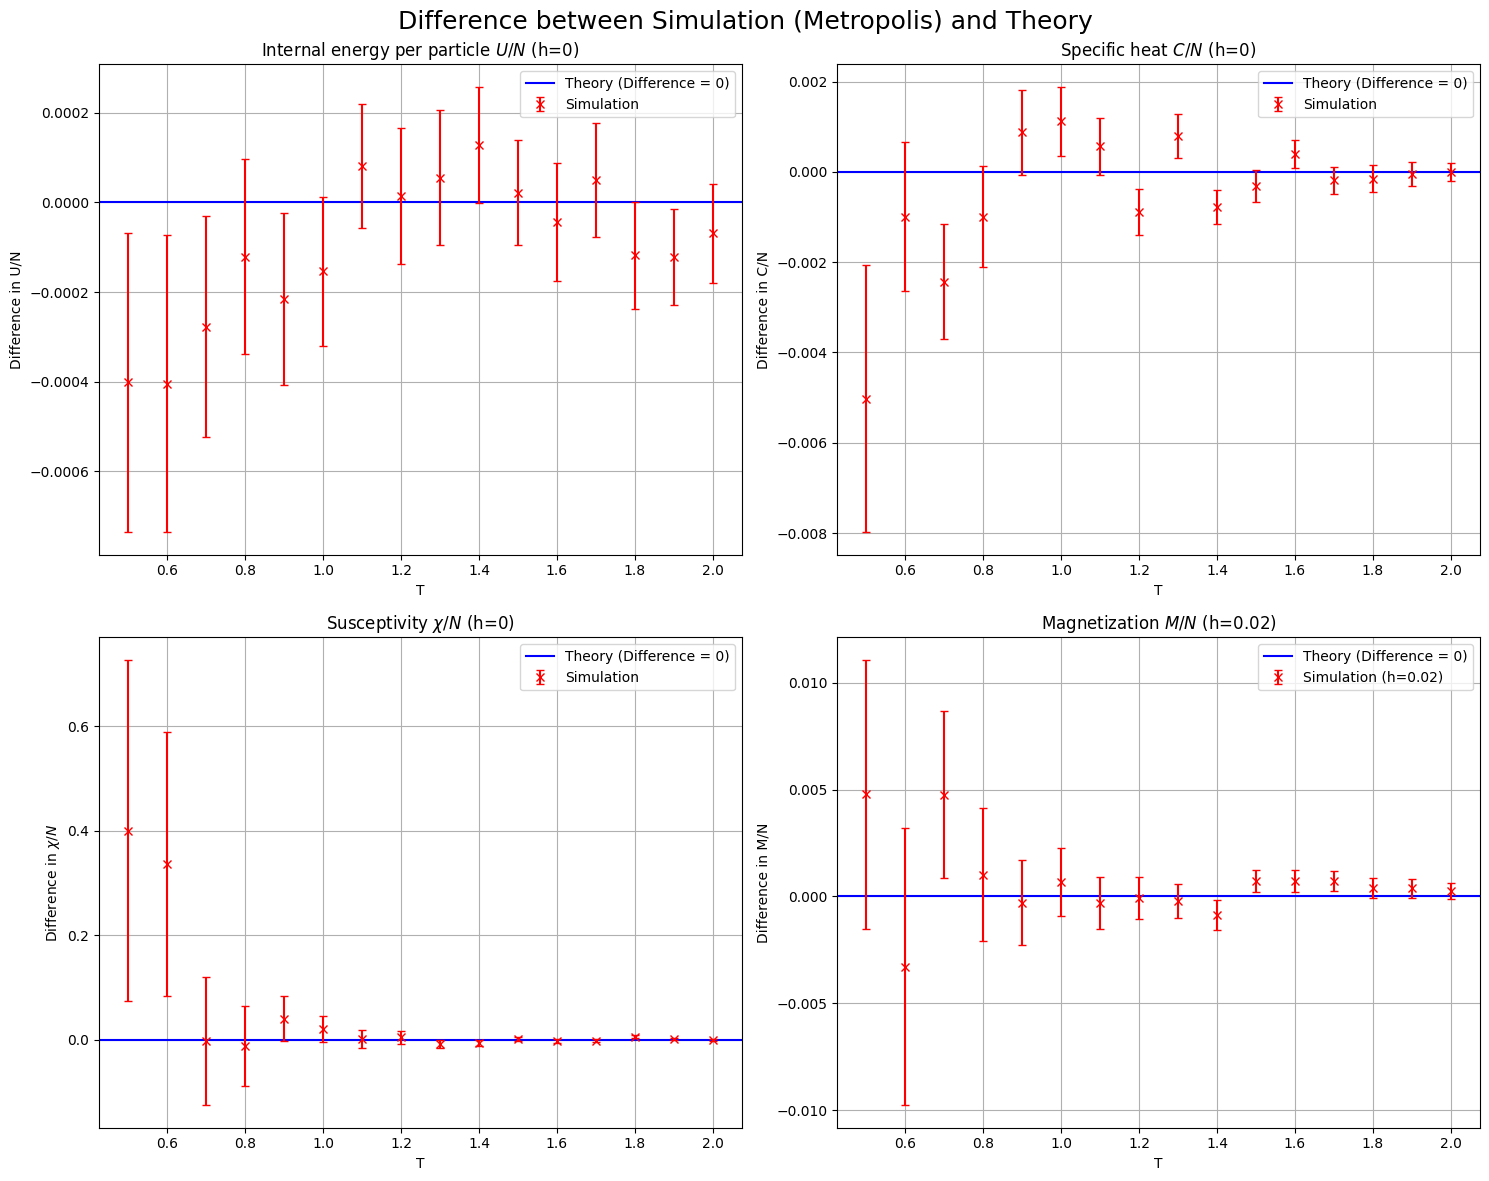

In [ ]:
# ============================================================
# Reading Data, Computing Differences & Plotting
# ============================================================

temperatures = np.arange(2.0, 0.49, -0.1)

U_sim, U_err = [], []
C_sim, C_err = [], []
X_sim, X_err = [], []
M_sim, M_err = [], []

# Read all data
for T_val in temperatures:
    t_str = f"{T_val:.2f}".replace('.', '_')
    append_data("total_energy", t_str, U_sim, U_err)
    append_data("specific_heat", t_str, C_sim, C_err)
    append_data("susceptibility", t_str, X_sim, X_err)
    append_data("magnetization", t_str, M_sim, M_err)

experimental_T = np.array(temperatures)

# Continuous theoretical curves for plotting
points = 200
T_smooth = np.linspace(0.4, 2.2, num=points)
e_exact = U(T_smooth)
cv_exact = cv(T_smooth)
chi_exact = chi(T_smooth)
M_exact = M(T_smooth, h)

# Compute differences (experimental - discrete theory)
diffs = [
    np.array(U_sim) - U(experimental_T) if U_sim else [],
    np.array(C_sim) - cv(experimental_T) if C_sim else [],
    np.array(X_sim) - chi(experimental_T) if X_sim else [],
    np.array(M_sim) - M(experimental_T, h) if M_sim else []
]

sims = [U_sim, C_sim, X_sim, M_sim]
errs = [U_err, C_err, X_err, M_err]
theo = [e_exact, cv_exact, chi_exact, M_exact]

labels = ['U/N', 'C/N', '$\chi/N$', 'M/N']
titles = ['Internal energy per particle $U/N$ (h=0)', 
          'Specific heat $C/N$ (h=0)', 
          'Susceptivity $\chi/N$ (h=0)', 
          'Magnetization $M/N$ (h=0.02)']

# ==========================================
# PLOTTING 1: ABSOLUTE VALUES
# ==========================================
fig_abs, axs_abs = plt.subplots(2, 2, figsize=(15, 12))
fig_abs.suptitle('1D Ising Model - Simulation (Metropolis) VS Theory', fontsize=18)

for k, ax in enumerate(axs_abs.flatten()):
        
    theo_label = 'Theory (h=0.02)' if k == 3 else 'Theory (h=0)'
    ax.plot(T_smooth, theo[k], label=theo_label, color='blue')
    
    if sims[k]:
        sim_label = 'Simulation (h=0.02)' if k == 3 else 'Simulation'
        ax.errorbar(experimental_T, sims[k], yerr=errs[k], fmt='x', capsize=3, color='red', label=sim_label)
    
    elif k == 3:
        ax.text(0.5, 0.5, "No simulation data.\nLaunch with h=0.02 for magnetization!", 
                ha='center', va='center', color='red', fontsize=12, 
                bbox=dict(facecolor='white', alpha=0.8), transform=ax.transAxes)

    ax.set_title(titles[k])
    ax.set_xlabel('T')
    ax.set_ylabel(labels[k])
    ax.grid(True)
    ax.legend()

plt.tight_layout()
plt.show()

# ==========================================
# PLOTTING 2: DIFFERENCES
# ==========================================
fig_diff, axs_diff = plt.subplots(2, 2, figsize=(15, 12))
fig_diff.suptitle('Difference between Simulation (Metropolis) and Theory', fontsize=18)

for k, ax in enumerate(axs_diff.flatten()):
    
    ax.axhline(0, color='blue', label='Theory (Difference = 0)')
    
    if len(diffs[k]) > 0:
        sim_label = 'Simulation (h=0.02)' if k == 3 else 'Simulation'
        ax.errorbar(experimental_T, diffs[k], yerr=errs[k], 
                    fmt='x', capsize=3, color='red', label=sim_label)
        
    elif k == 3:
        ax.text(0.5, 0.5, "No simulation data.\nLaunch with h=0.02 for magnetization!", 
                ha='center', va='center', color='red', fontsize=12, 
                bbox=dict(facecolor='white', alpha=0.8), transform=ax.transAxes)

    ax.set_title(titles[k])
    ax.set_xlabel('T')
    ax.set_ylabel(f'Difference in {labels[k]}')
    ax.grid(True)
    ax.legend()

plt.tight_layout()
plt.show()

### Data Blocking

In order to better understand the convergence process I decided to also plot the progressive mean and error for three temperatures $T=2.0$, $T=1.0$ and $T=0.5$.

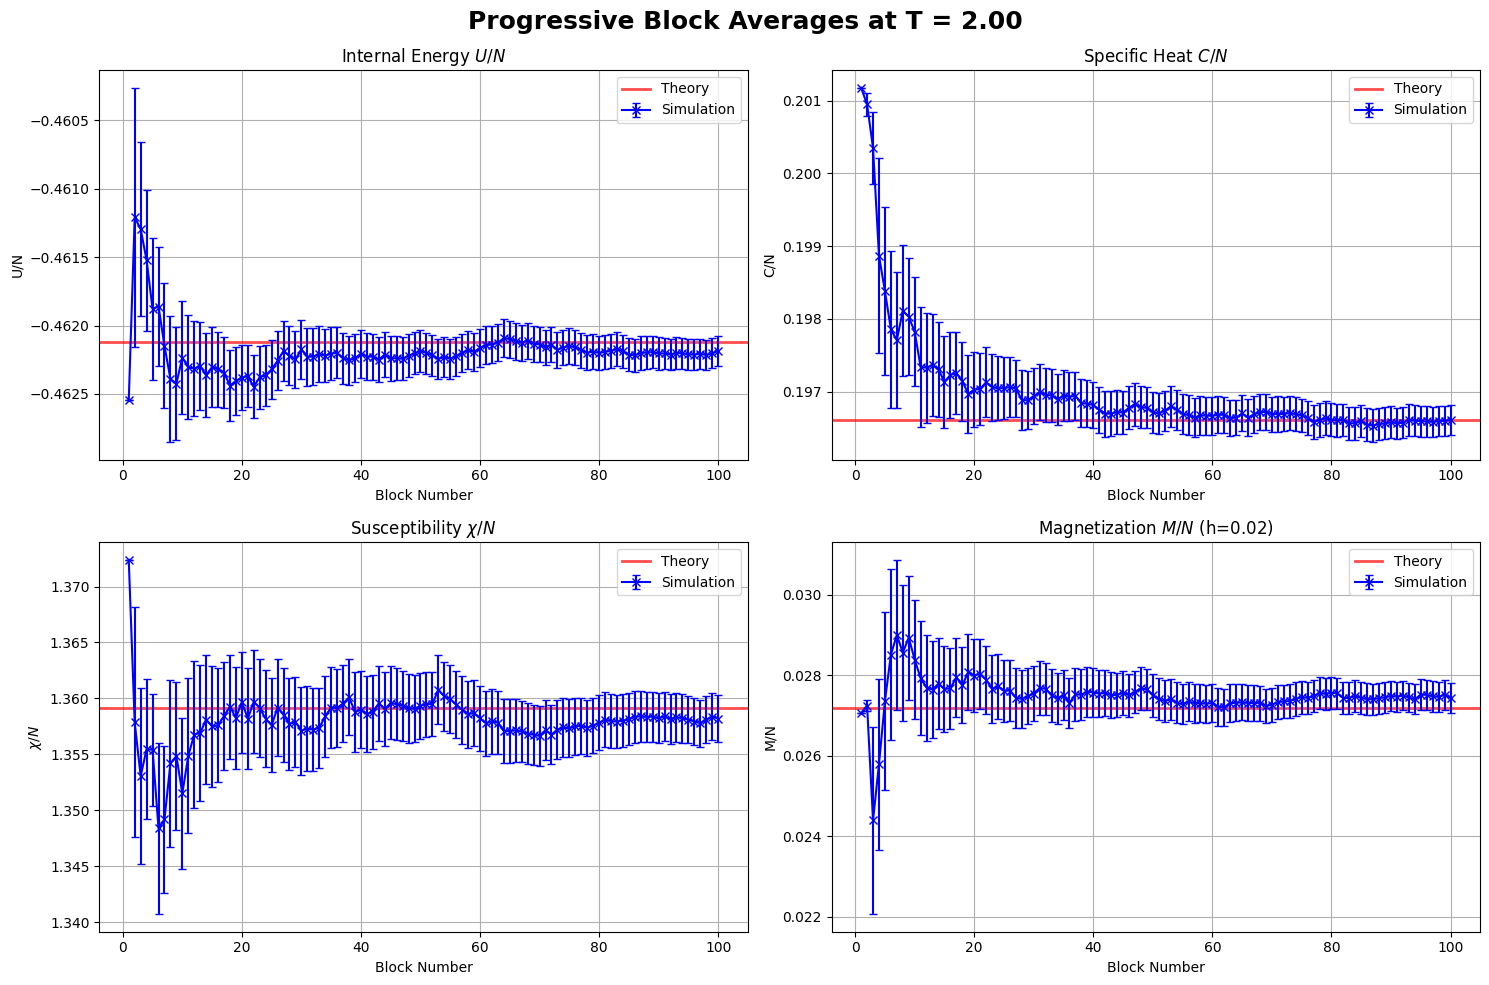

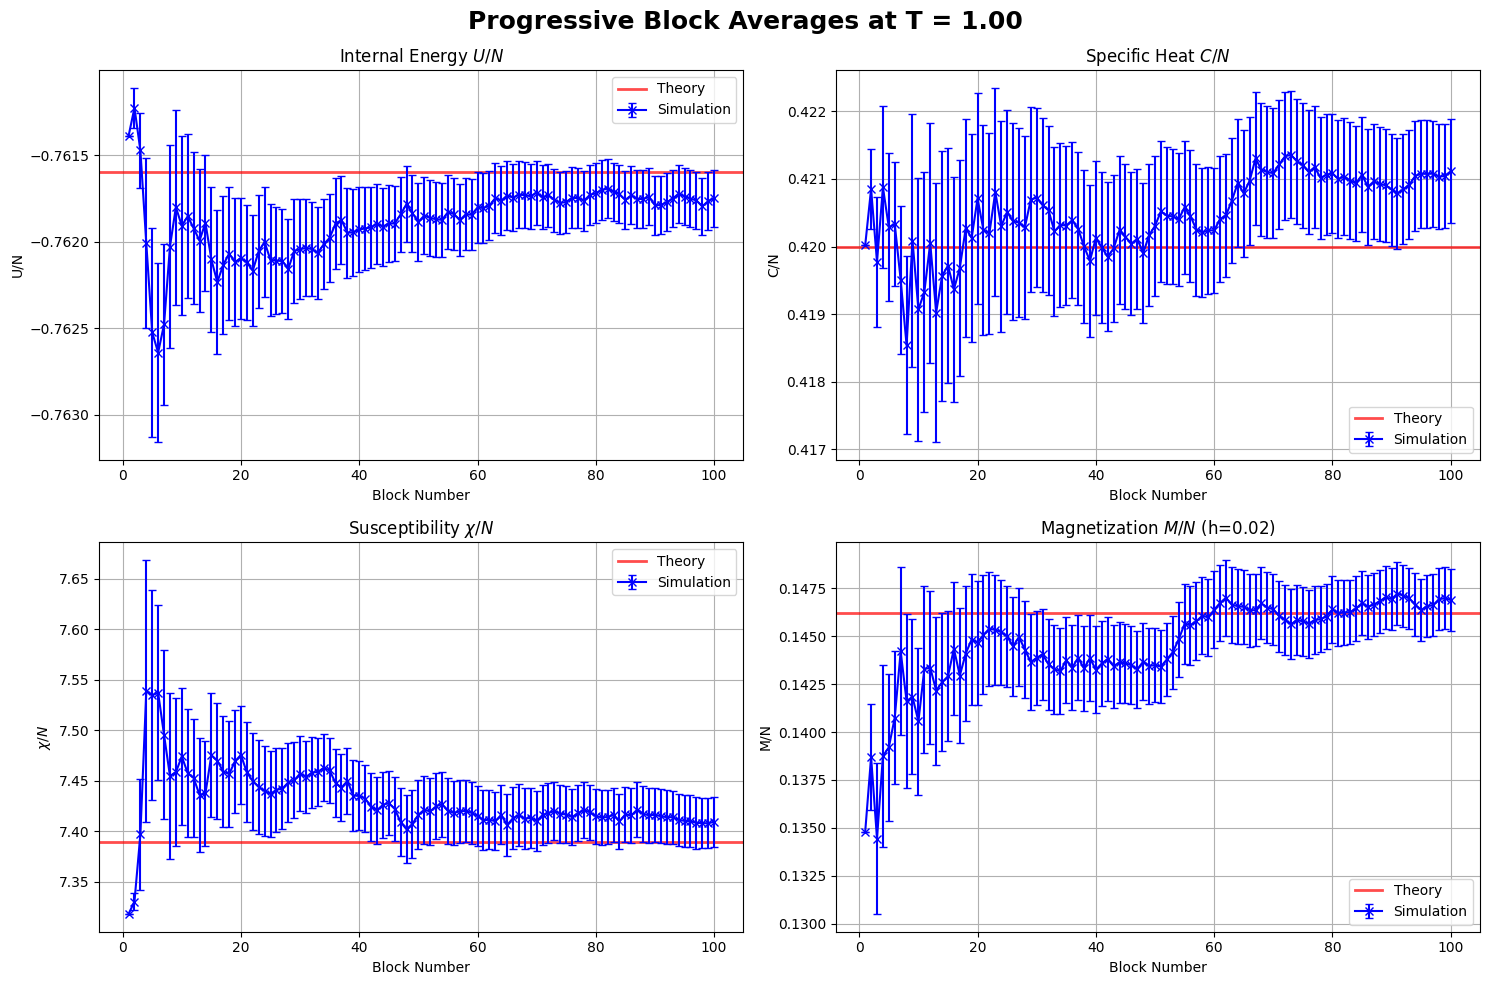

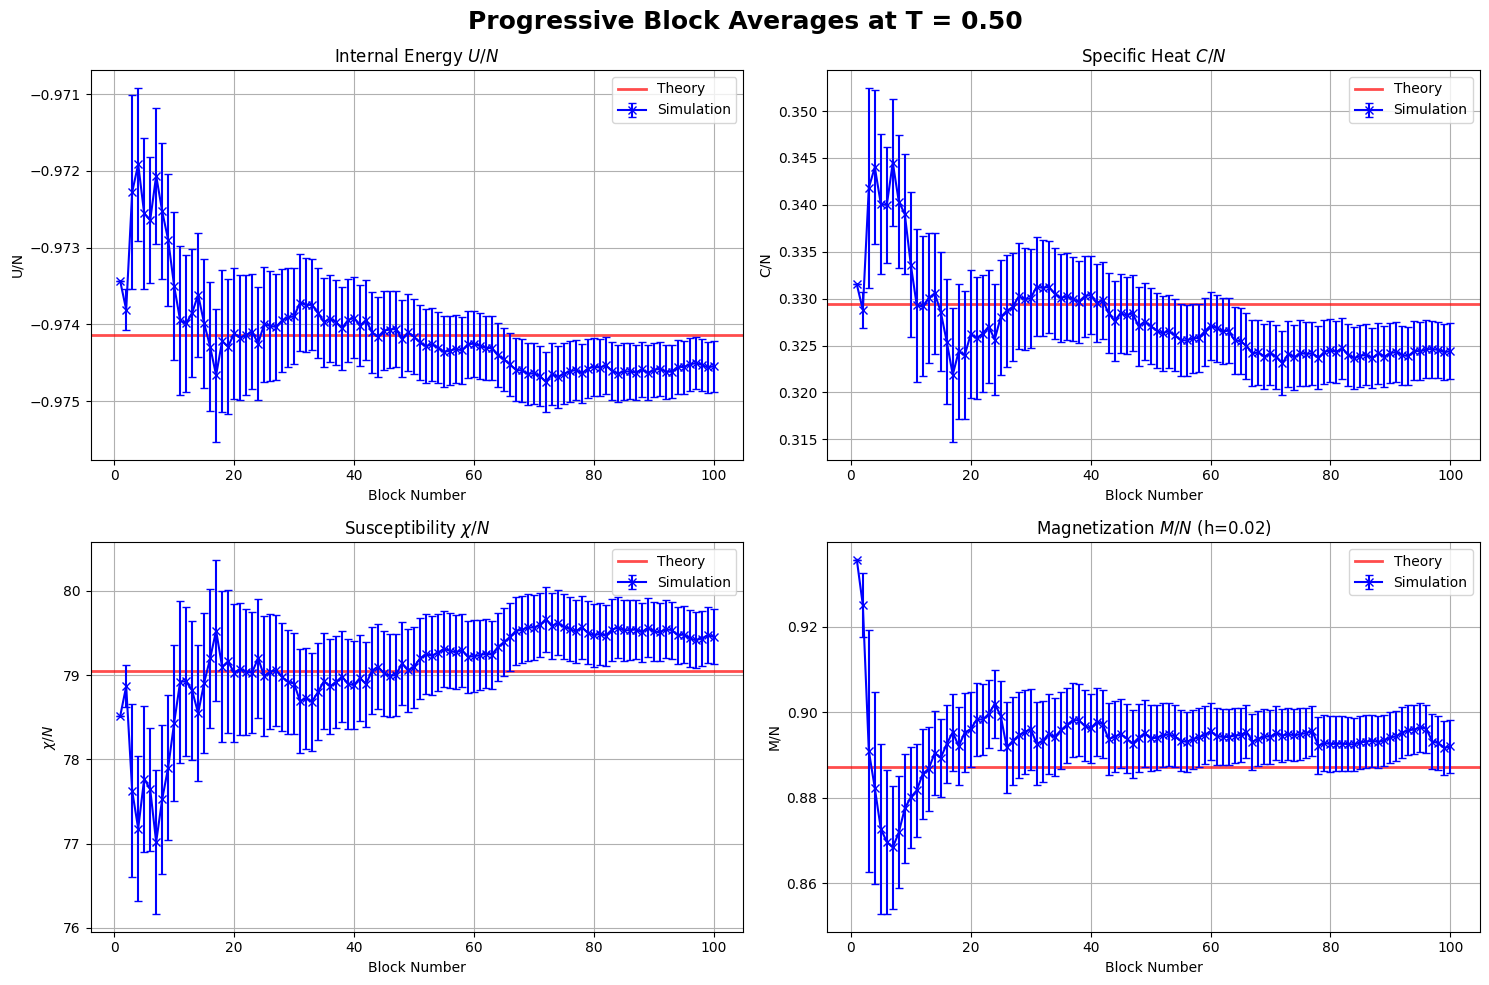

In [35]:
# ==========================================
# PLOTTING DATA BLOCKING
# ==========================================
target_temps = [2.0, 1.0, 0.5]

observables = [
    {'prefix': 'total_energy', 'title': 'Internal Energy $U/N$', 'ylab': 'U/N', 'theo': U},
    {'prefix': 'specific_heat', 'title': 'Specific Heat $C/N$', 'ylab': 'C/N', 'theo': cv},
    {'prefix': 'susceptibility', 'title': 'Susceptibility $\chi/N$', 'ylab': '$\chi/N$', 'theo': chi},
    {'prefix': 'magnetization', 'title': 'Magnetization $M/N$ (h=0.02)', 'ylab': 'M/N', 'theo': lambda t: M(t, h)}
]

for T_val in target_temps:
    fig, axs = plt.subplots(2, 2, figsize=(15, 10))
    fig.suptitle(f'Progressive Block Averages at T = {T_val:.2f}', fontsize=18, fontweight='bold')
    t_str = f"{T_val:.2f}".replace('.', '_')
    
    for ax, obs in zip(axs.flatten(), observables):
        # Plot theory line (always executes)
        ax.axhline(obs['theo'](T_val), color='red', lw=2, alpha=0.7, label='Theory')
        
        # Try plotting simulation data
        try:
            data = load_file(os.path.join(out_dir_M, f"{obs['prefix']}_{t_str}.dat"))
            ax.errorbar(data[:, 0], data[:, 2], yerr=data[:, 3], fmt='x-', color='blue', capsize=3, label='Simulation')
        except OSError:
            ax.text(0.5, 0.5, f"No simulation data.", ha='center', va='center', color='red', 
                    bbox=dict(facecolor='white', alpha=0.8), transform=ax.transAxes)

        # Formatting
        ax.set(title=obs['title'], xlabel='Block Number', ylabel=obs['ylab'])
        ax.grid(True)
        ax.legend()

    plt.tight_layout()
    plt.subplots_adjust(top=0.92) 
    plt.show()

## Results: Gibbs

For the Gibbs algorithm I did essentially the same things. I report the plots for the comparison with the theoretical curve, the plot of the differences to highlight the error bars and the data blocking progressive mean and error for $T=2.0$, $T=1.0$ and $T=0.5$.

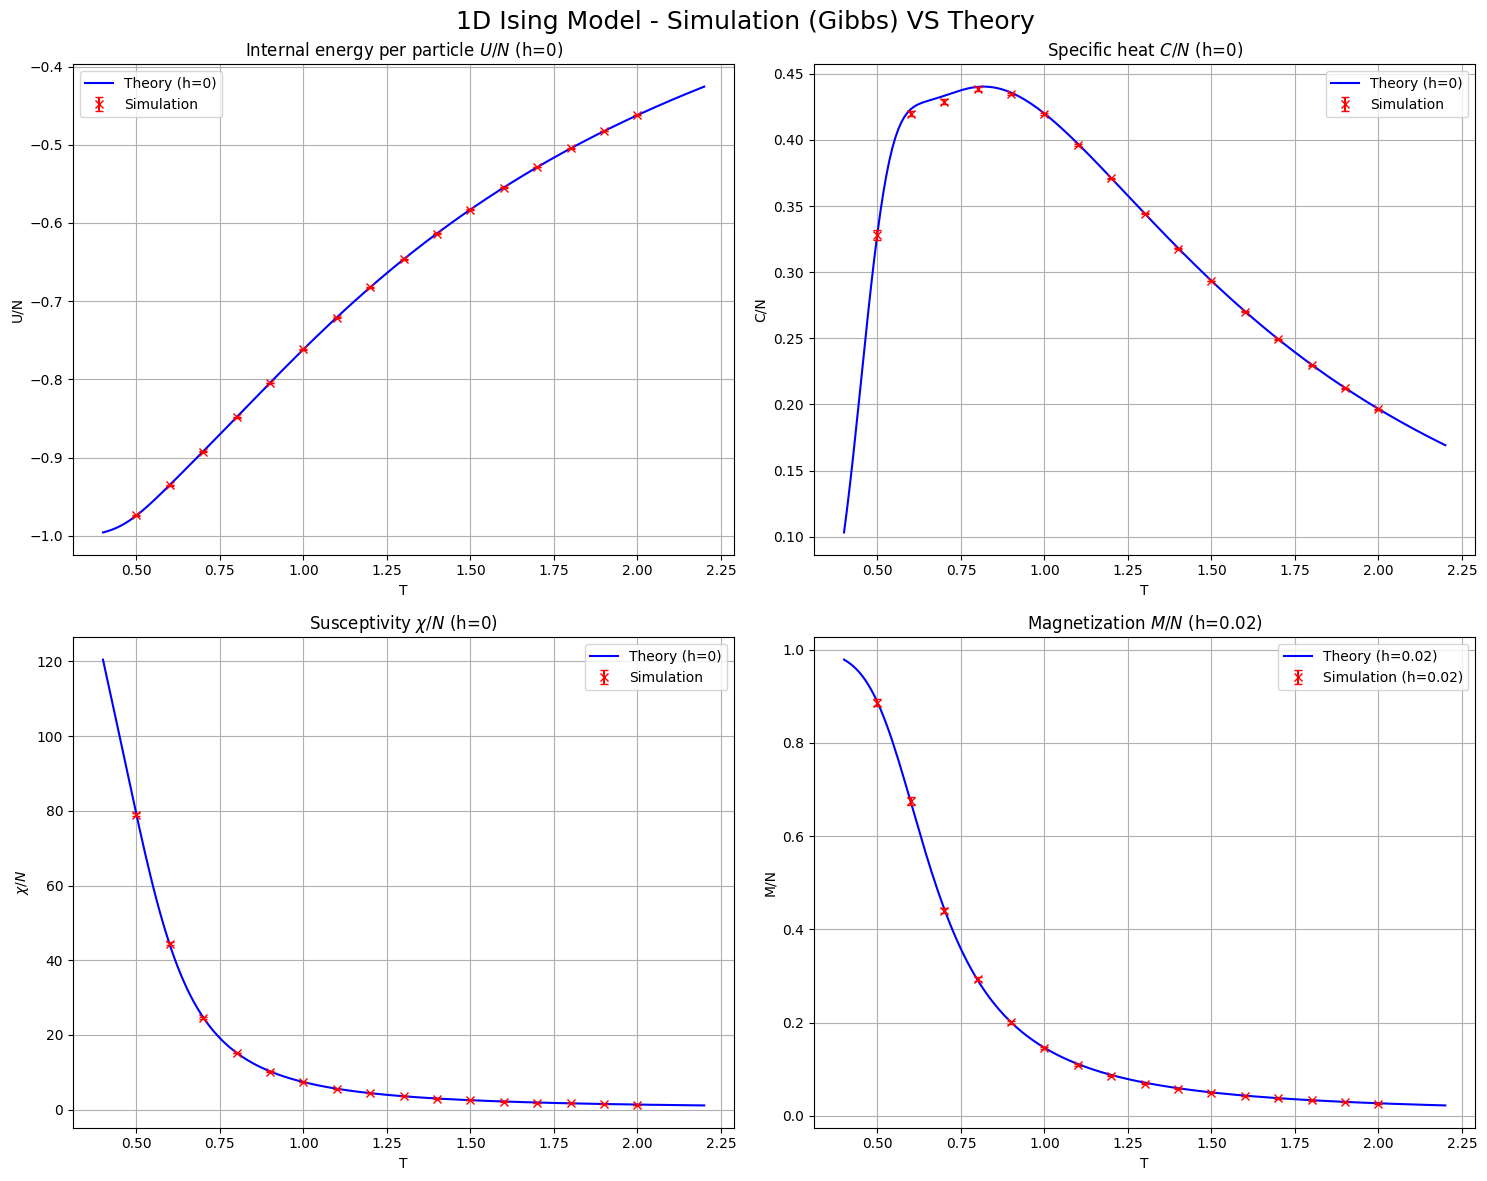

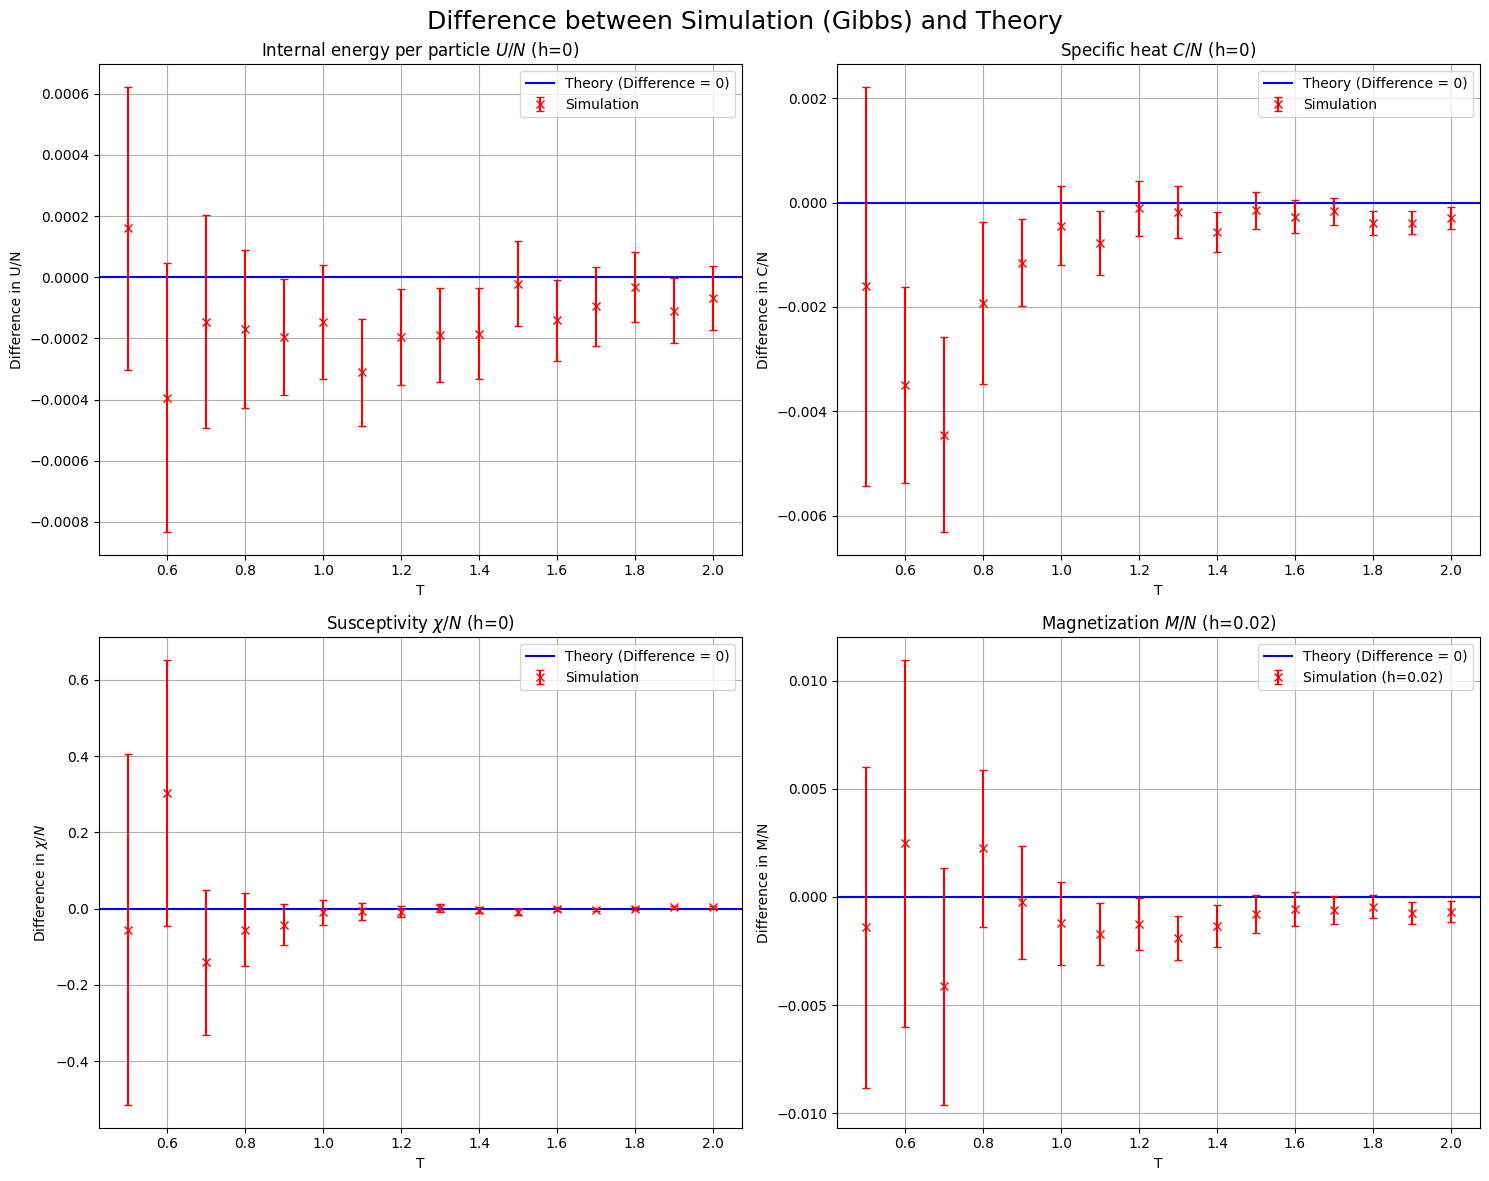

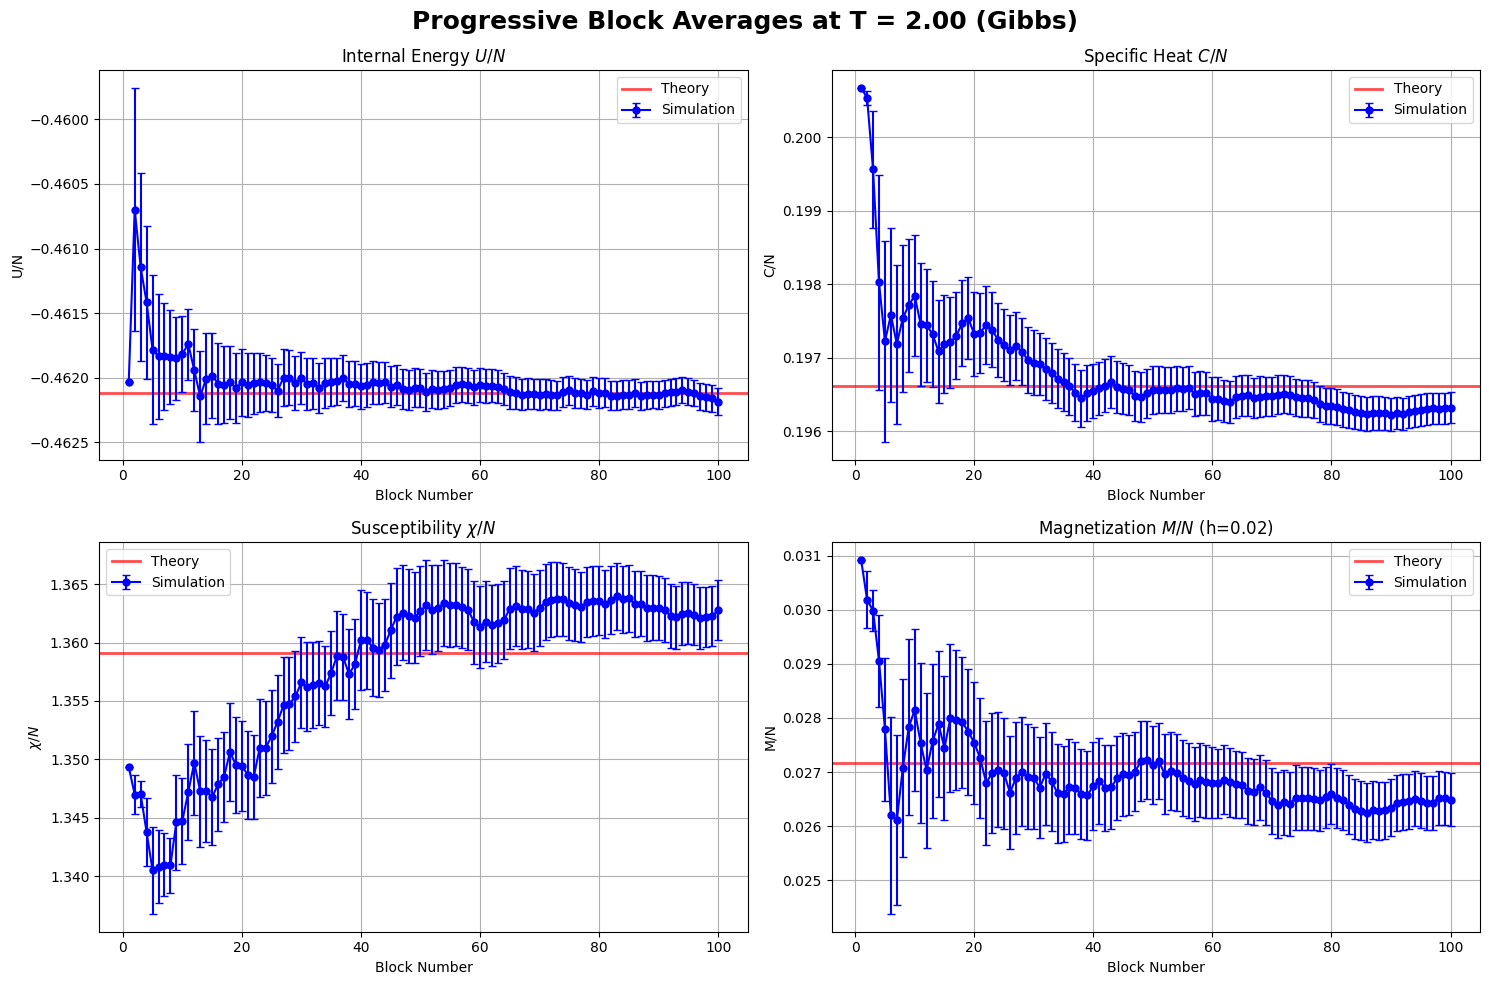

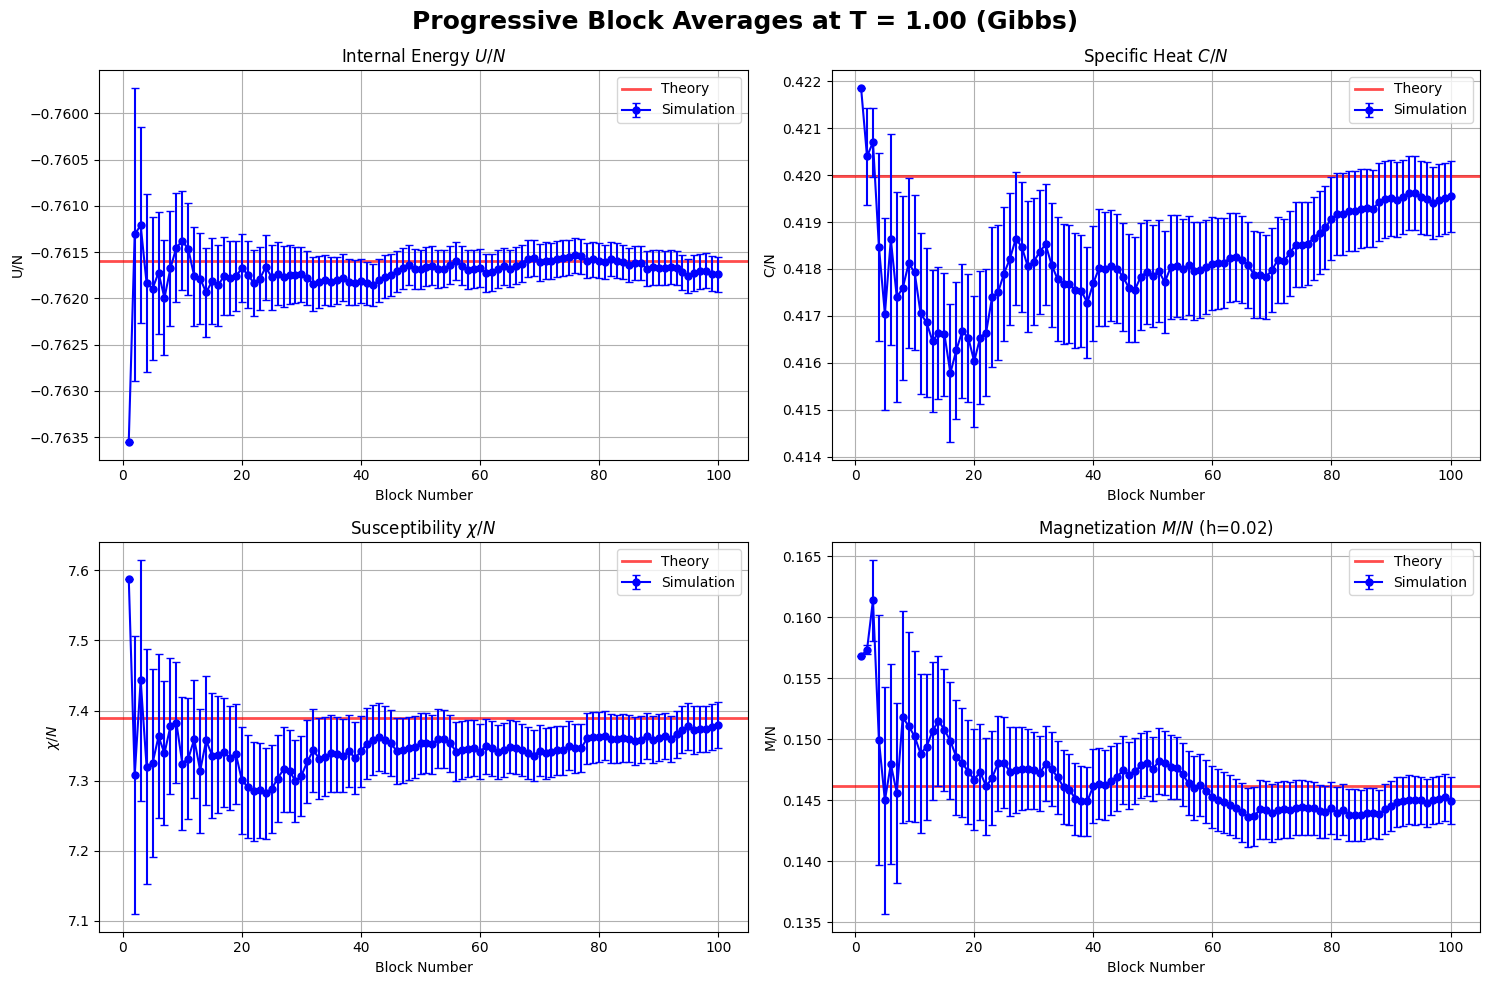

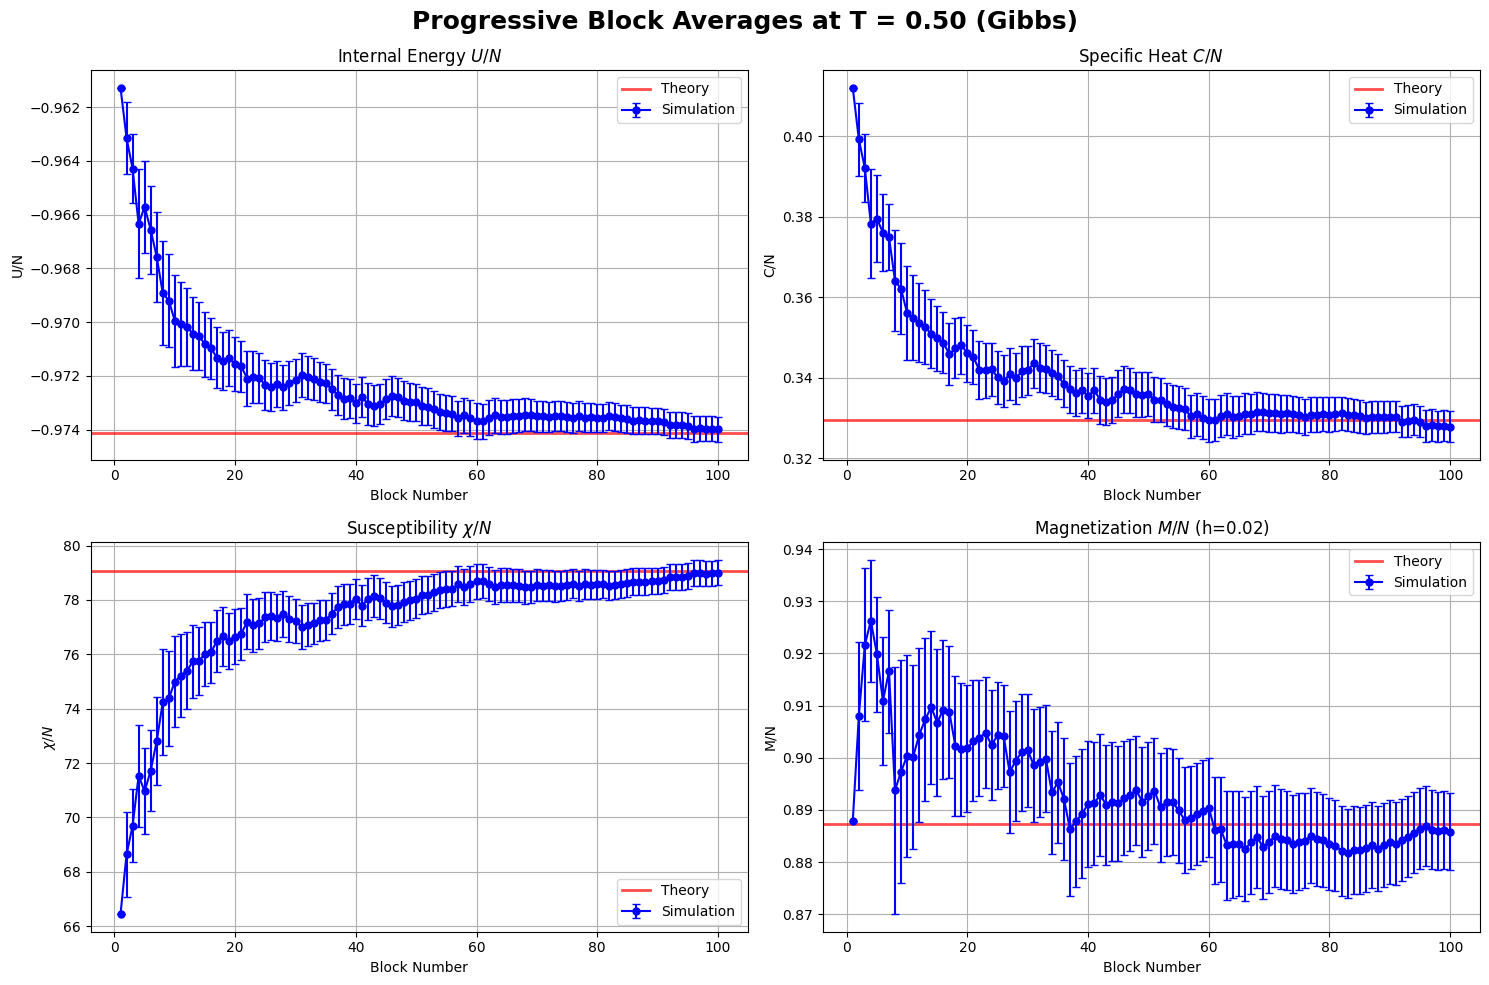

In [34]:
# ============================================================
# Reading Data & Computing Differences (GIBBS)
# ============================================================
temperatures = np.arange(2.0, 0.49, -0.1)
experimental_T = np.array(temperatures)

U_sim, U_err, C_sim, C_err = [], [], [], []
X_sim, X_err, M_sim, M_err = [], [], [], []

def append_data(prefix, t_string, sim_list, err_list):
    try:
        data = load_file(os.path.join(out_dir_G, f"{prefix}_{t_string}.dat"))
        sim_list.append(data[-1, 2])
        err_list.append(data[-1, 3])
    except OSError: pass

for T_val in temperatures:
    t_str = f"{T_val:.2f}".replace('.', '_')
    append_data("total_energy", t_str, U_sim, U_err)
    append_data("specific_heat", t_str, C_sim, C_err)
    append_data("susceptibility", t_str, X_sim, X_err)
    append_data("magnetization", t_str, M_sim, M_err)

# Theoretical curves
T_smooth = np.linspace(0.4, 2.2, num=200)
theo_smooth = [U(T_smooth), cv(T_smooth), chi(T_smooth), M(T_smooth, h)]

# Differences (experimental - discrete theory)
diffs = [
    np.array(U_sim) - U(experimental_T) if U_sim else [],
    np.array(C_sim) - cv(experimental_T) if C_sim else [],
    np.array(X_sim) - chi(experimental_T) if X_sim else [],
    np.array(M_sim) - M(experimental_T, h) if M_sim else []
]

sims = [U_sim, C_sim, X_sim, M_sim]
errs = [U_err, C_err, X_err, M_err]

labels = ['U/N', 'C/N', '$\chi/N$', 'M/N']
titles = ['Internal energy per particle $U/N$ (h=0)', 
          'Specific heat $C/N$ (h=0)', 
          'Susceptivity $\chi/N$ (h=0)', 
          'Magnetization $M/N$ (h=0.02)']

# ==========================================
# PLOTTING 1: ABSOLUTE VALUES & DIFFERENCES
# ==========================================
fig_abs, axs_abs = plt.subplots(2, 2, figsize=(15, 12))
fig_abs.suptitle('1D Ising Model - Simulation (Gibbs) VS Theory', fontsize=18)

fig_diff, axs_diff = plt.subplots(2, 2, figsize=(15, 12))
fig_diff.suptitle('Difference between Simulation (Gibbs) and Theory', fontsize=18)

for k in range(4):
    ax_a, ax_d = axs_abs.flatten()[k], axs_diff.flatten()[k]
    
    # Absolute plot lines
    theo_label = 'Theory (h=0.02)' if k == 3 else 'Theory (h=0)'
    ax_a.plot(T_smooth, theo_smooth[k], label=theo_label, color='blue')
    
    # Difference plot lines
    ax_d.axhline(0, color='blue', label='Theory (Difference = 0)')
    
    if sims[k]:
        sim_label = 'Simulation (h=0.02)' if k == 3 else 'Simulation'
        ax_a.errorbar(experimental_T, sims[k], yerr=errs[k], fmt='x', capsize=3, color='red', label=sim_label)
        ax_d.errorbar(experimental_T, diffs[k], yerr=errs[k], fmt='x', capsize=3, color='red', label=sim_label)
    elif k == 3:
        msg = "No simulation data.\nLaunch with h=0.02!"
        kwargs = dict(ha='center', va='center', color='red', bbox=dict(facecolor='white', alpha=0.8))
        ax_a.text(0.5, 0.5, msg, transform=ax_a.transAxes, **kwargs)
        ax_d.text(0.5, 0.5, msg, transform=ax_d.transAxes, **kwargs)

    # Formatting both subplots
    ax_a.set(title=titles[k], xlabel='T', ylabel=labels[k])
    ax_d.set(title=titles[k], xlabel='T', ylabel=f'Difference in {labels[k]}')
    
    for ax in (ax_a, ax_d):
        ax.grid(True)
        ax.legend()

fig_abs.tight_layout(); fig_diff.tight_layout()
plt.show()

# ==========================================
# PLOTTING 2: DATA BLOCKING (GIBBS)
# ==========================================
target_temps = [2.0, 1.0, 0.5]
observables = [
    {'prefix': 'total_energy', 'title': 'Internal Energy $U/N$', 'ylab': 'U/N', 'theo': U},
    {'prefix': 'specific_heat', 'title': 'Specific Heat $C/N$', 'ylab': 'C/N', 'theo': cv},
    {'prefix': 'susceptibility', 'title': 'Susceptibility $\chi/N$', 'ylab': '$\chi/N$', 'theo': chi},
    {'prefix': 'magnetization', 'title': 'Magnetization $M/N$ (h=0.02)', 'ylab': 'M/N', 'theo': lambda t: M(t, h)}
]

for T_val in target_temps:
    fig, axs = plt.subplots(2, 2, figsize=(15, 10))
    fig.suptitle(f'Progressive Block Averages at T = {T_val:.2f} (Gibbs)', fontsize=18, fontweight='bold')
    t_str = f"{T_val:.2f}".replace('.', '_')
    
    for ax, obs in zip(axs.flatten(), observables):
        # Theory line
        ax.axhline(obs['theo'](T_val), color='red', lw=2, alpha=0.7, label='Theory')
        
        try:
            data = load_file(os.path.join(out_dir_G, f"{obs['prefix']}_{t_str}.dat"))
            ax.errorbar(data[:, 0], data[:, 2], yerr=data[:, 3], fmt='o-', color='blue', capsize=3, markersize=5, label='Simulation')
        except OSError:
            ax.text(0.5, 0.5, f"No simulation data.", ha='center', va='center', color='red', 
                    bbox=dict(facecolor='white', alpha=0.8), transform=ax.transAxes)

        ax.set(title=obs['title'], xlabel='Block Number', ylabel=obs['ylab'])
        ax.grid(True)
        ax.legend()

    plt.tight_layout()
    plt.subplots_adjust(top=0.92) 
    plt.show()

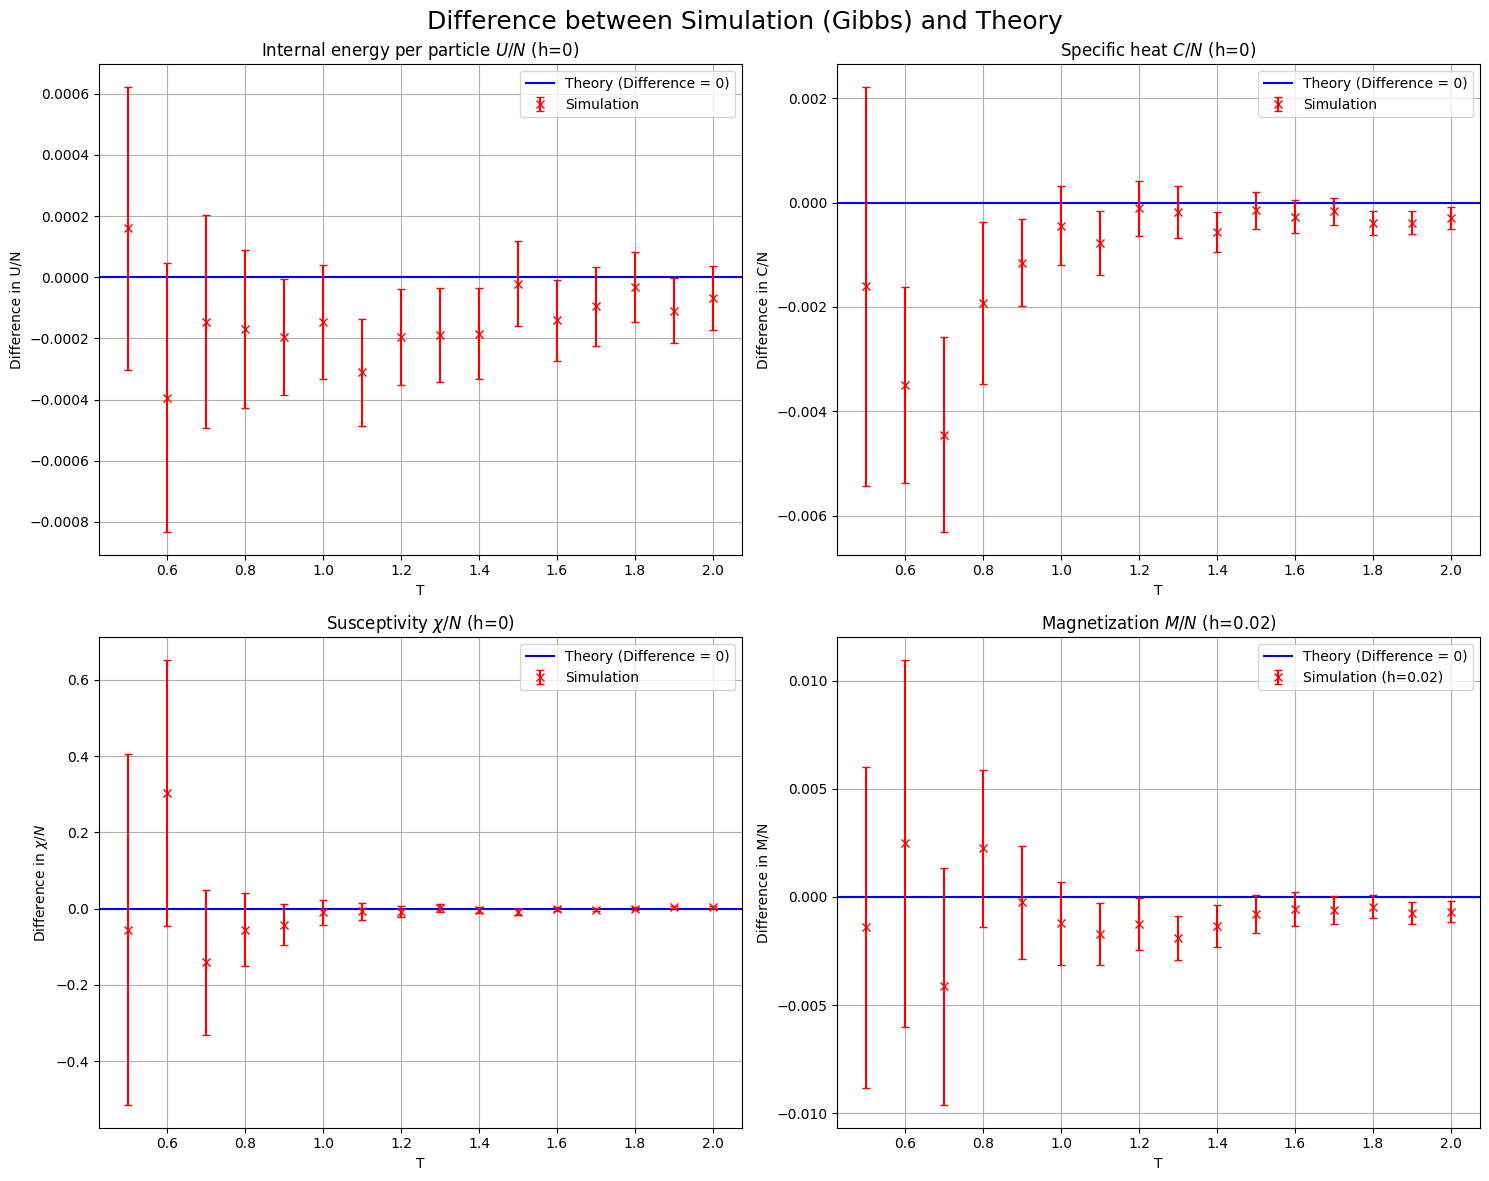

In [17]:
# Plotting the difference between simulation and theory for each observable

experimental_T = np.array(temperatures)

data = []

# Energy
if U_sim:
    diff_U = np.array(U_sim) - U(experimental_T[:len(U_sim)])
    data.append(diff_U)
else:
    data.append([])

# Specific heat
if C_sim:
    diff_C = np.array(C_sim) - cv(experimental_T[:len(C_sim)])
    data.append(diff_C)
else:
    data.append([])

# Susceptivity
if X_sim:
    diff_X = np.array(X_sim) - chi(experimental_T[:len(X_sim)])
    data.append(diff_X)
else:
    data.append([])

# Magnetization
if M_sim:
    diff_M = np.array(M_sim) - M(experimental_T[:len(M_sim)], h)
    data.append(diff_M)
else:
    data.append([])

# ==========================================
# PLOTTING DIFFERENCES
# ==========================================
fig_diff, axs_diff = plt.subplots(2, 2, figsize=(15, 12))
fig_diff.suptitle('Difference between Simulation (Gibbs) and Theory', fontsize=18)

errs = [U_err, C_err, X_err, M_err]
labels = ['U/N', 'C/N', '$\chi/N$', 'M/N']
titles = ['Internal energy per particle $U/N$ (h=0)', 
          'Specific heat $C/N$ (h=0)', 
          'Susceptivity $\chi/N$ (h=0)', 
          'Magnetization $M/N$ (h=0.02)']

for k, ax in enumerate(axs_diff.flatten()):
    
    ax.axhline(0, color='blue', label='Theory (Difference = 0)')
    
    if len(data[k]) > 0:
        sim_label = 'Simulation (h=0.02)' if k == 3 else 'Simulation'
        ax.errorbar(experimental_T, data[k], yerr=errs[k], 
                    capsize=3, fmt='x', color='red', label=sim_label)
        
    elif k == 3:
        ax.text(0.5, 0.5, "No simulation data.\nLaunch with h=0.02 for magnetization!", 
                ha='center', va='center', color='red', fontsize=12, 
                bbox=dict(facecolor='white', alpha=0.8), transform=ax.transAxes)

    ax.set_title(titles[k])
    ax.set_xlabel('T')
    ax.set_ylabel(f'Difference in {labels[k]}')
    ax.grid(True)
    ax.legend()

plt.tight_layout()
plt.show()

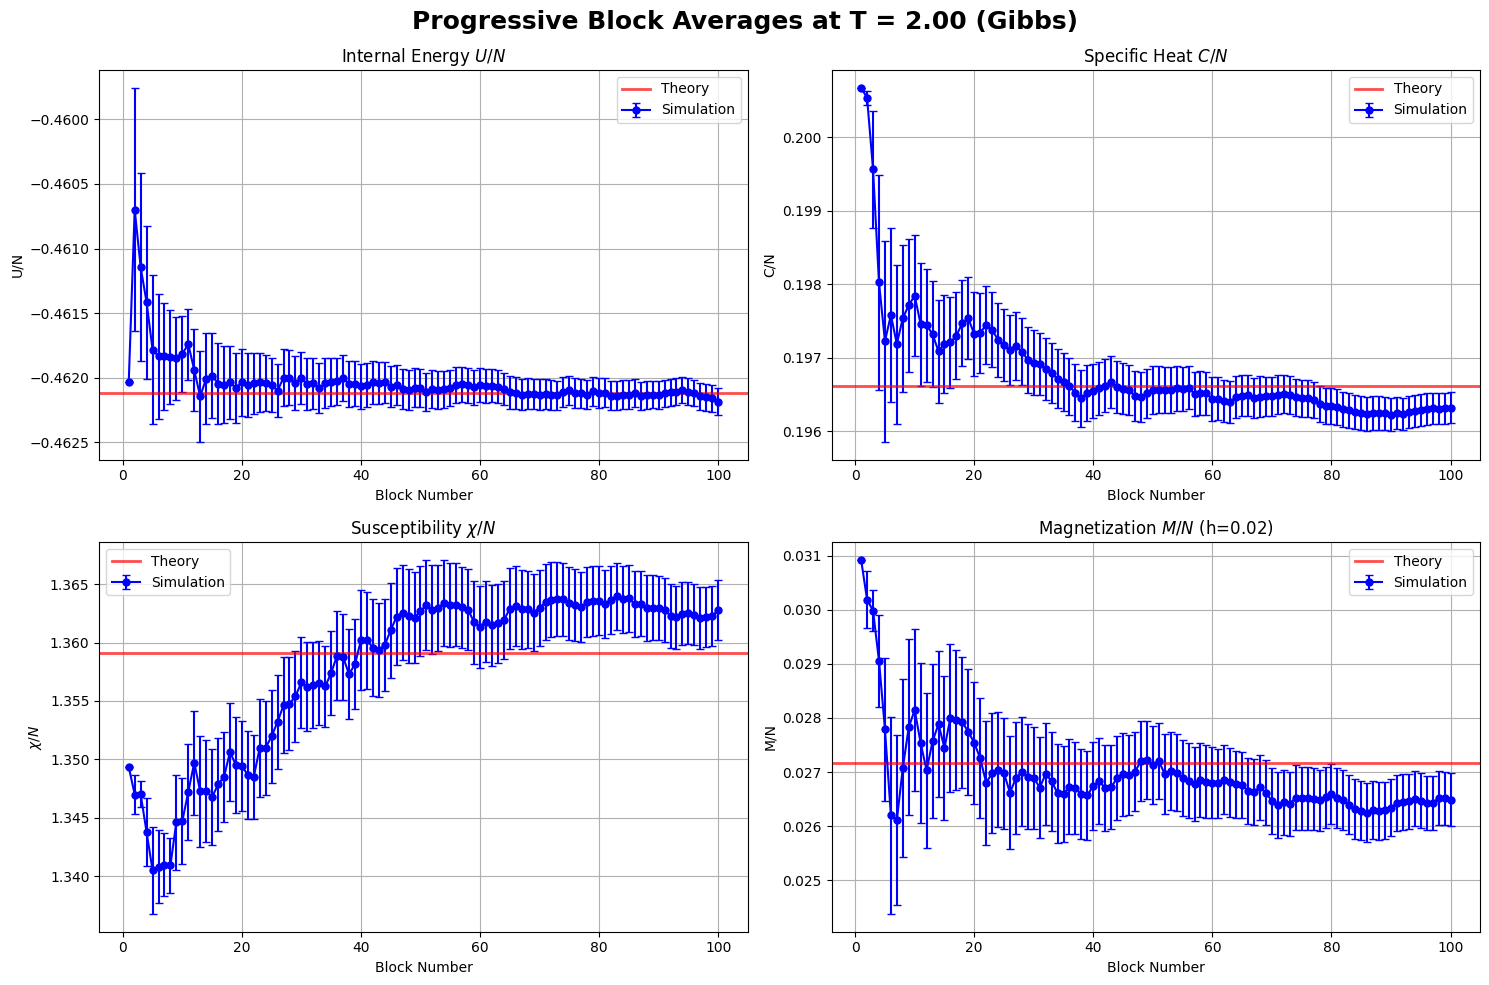

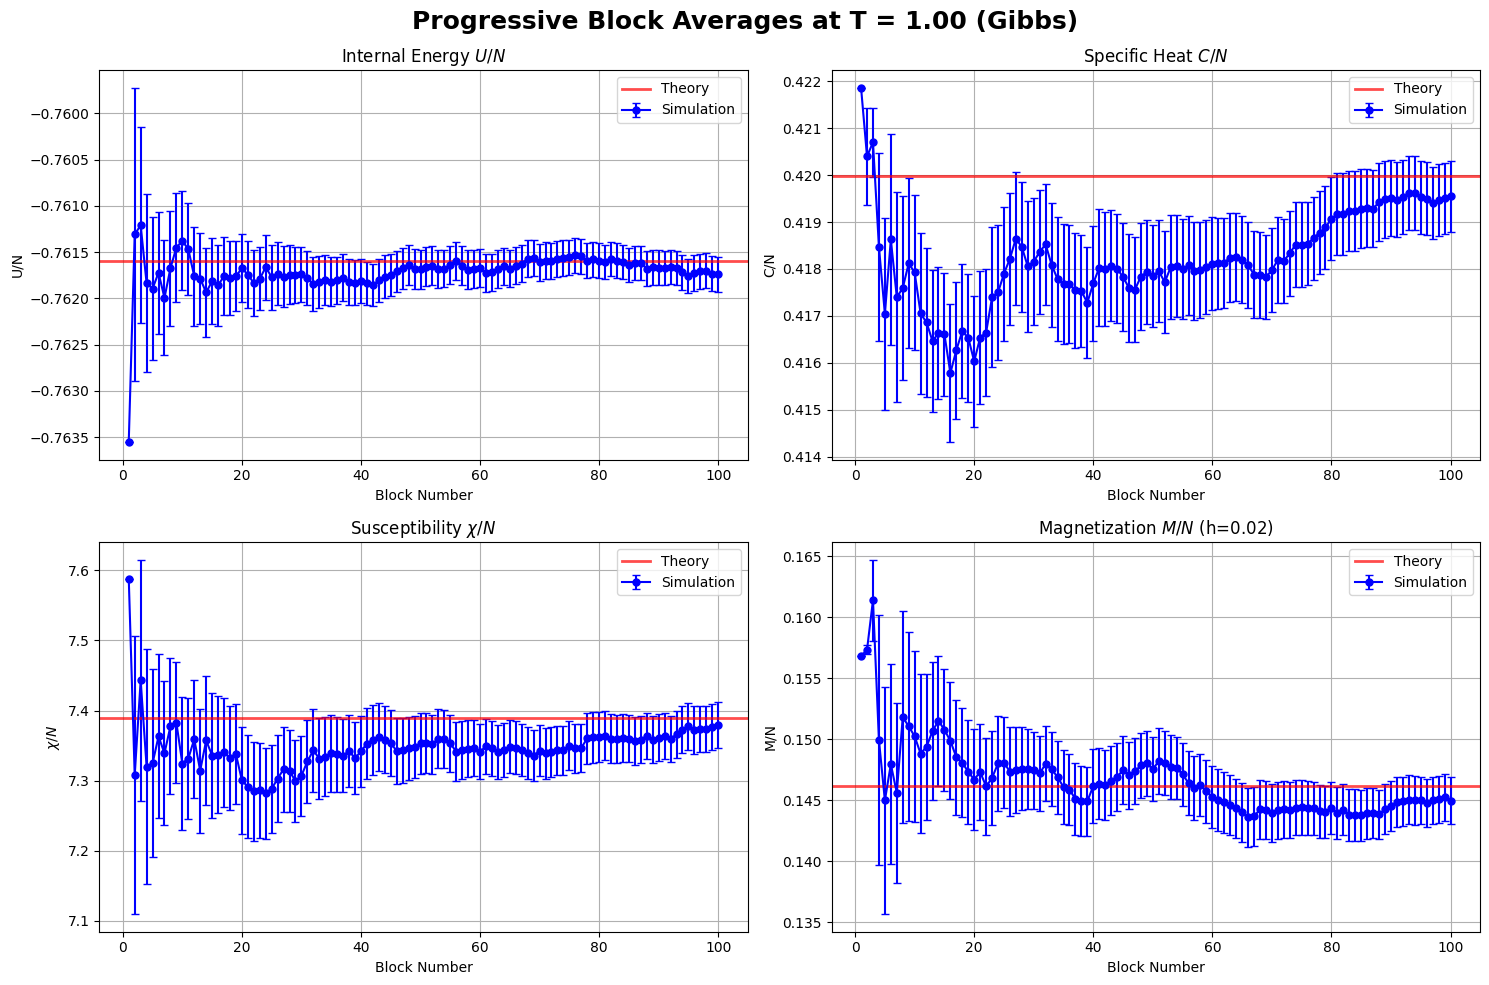

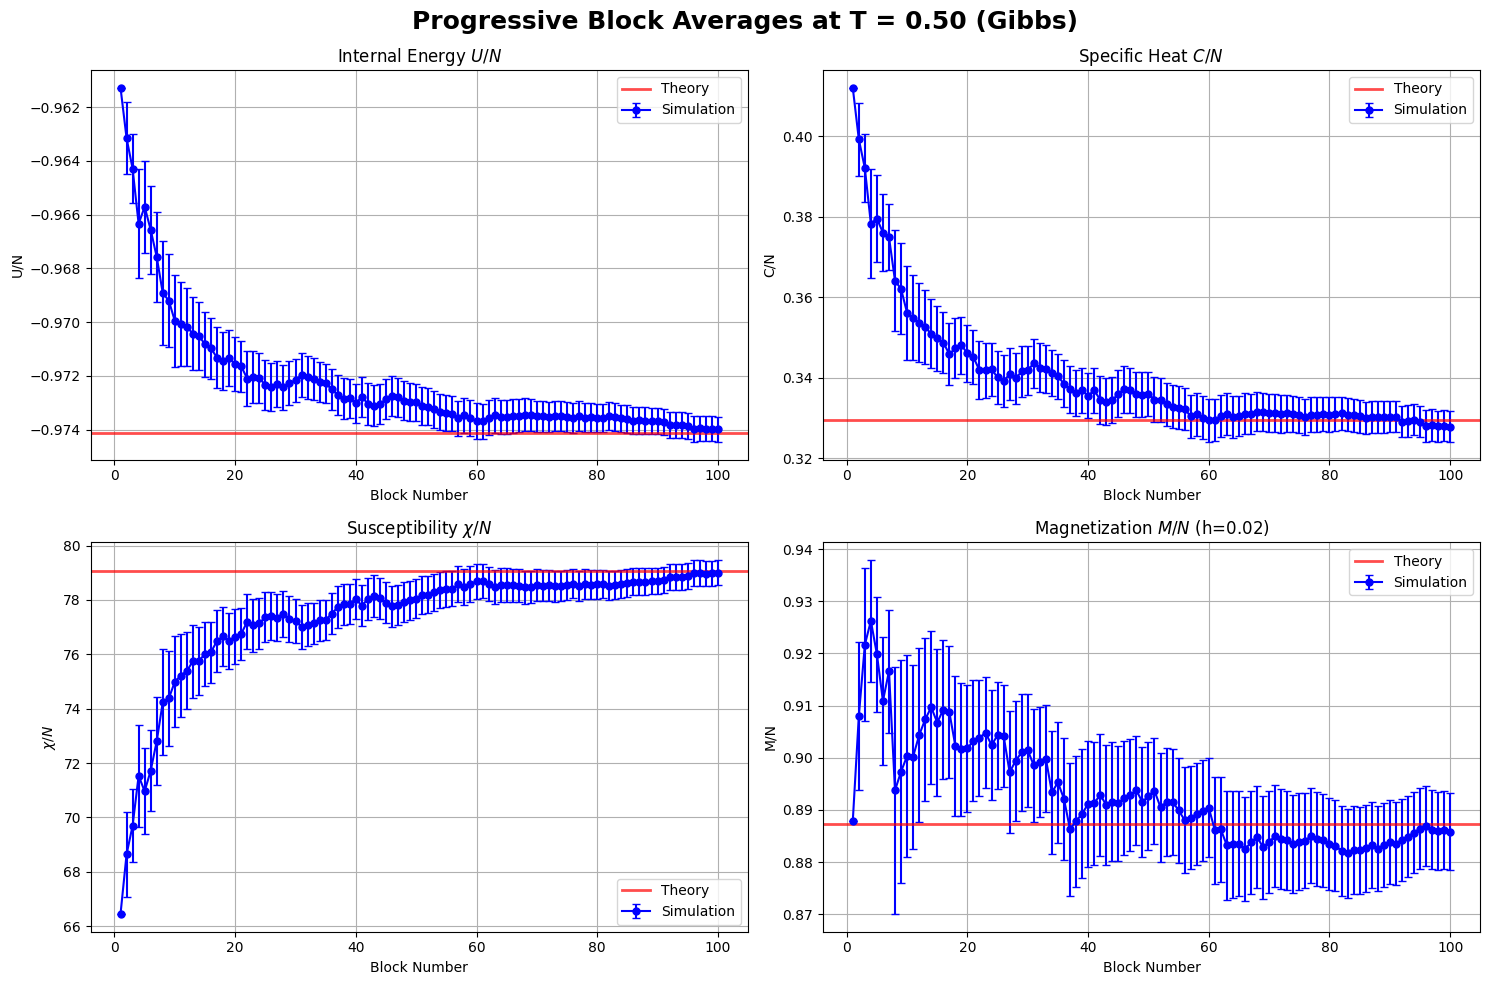

In [18]:
# ==========================================
# PLOTTING DATA BLOCKING (GIBBS)
# ==========================================
# Choose three temperatures

target_temps = [2.0, 1.0, 0.5]

observables = [
    {'prefix': 'total_energy', 'title': 'Internal Energy $U/N$', 'ylabel': 'U/N', 'theo_func': lambda t: U(t)},
    {'prefix': 'specific_heat', 'title': 'Specific Heat $C/N$', 'ylabel': 'C/N', 'theo_func': lambda t: cv(t)},
    {'prefix': 'susceptibility', 'title': 'Susceptibility $\chi/N$', 'ylabel': '$\chi/N$', 'theo_func': lambda t: chi(t)},
    {'prefix': 'magnetization', 'title': 'Magnetization $M/N$ (h=0.02)', 'ylabel': 'M/N', 'theo_func': lambda t: M(t, h)}
]

for T_val in target_temps:
    
    fig, axs = plt.subplots(2, 2, figsize=(15, 10))
    fig.suptitle(f'Progressive Block Averages at T = {T_val:.2f} (Gibbs)', fontsize=18, fontweight='bold')
    
    t_str = f"{T_val:.2f}".replace('.', '_')
    
    for k, obs in enumerate(observables):
        ax = axs.flatten()[k]
        filepath = os.path.join(out_dir_G, f"{obs['prefix']}_{t_str}.dat")
        
        exact_value = obs['theo_func'](T_val)
        
        try:
            data = load_file(filepath)
            
            blocks = data[:, 0]
            averages = data[:, 2]
            errors = data[:, 3]
            
            # Simulazione in blu
            ax.errorbar(blocks, averages, yerr=errors, marker='o', markersize=5, 
                        linestyle='-', linewidth=1.5, color='blue', ecolor='blue', capsize=3, label='Simulation')
            
            # Teoria in rosso
            ax.axhline(exact_value, color='red', linestyle='-', linewidth=2, alpha=0.7, label='Theory')
            
            ax.legend()
            
        except OSError:
            # Corretto il colore della teoria (da blu a rosso) per coerenza con il blocco try
            ax.axhline(exact_value, color='red', linestyle='-', linewidth=2, alpha=0.7, label='Theory')
            ax.text(0.5, 0.5, f"No simulation data.\n(File {obs['prefix']}_{t_str}.dat missing)", 
                    ha='center', va='center', color='red', fontsize=12, 
                    bbox=dict(facecolor='white', alpha=0.8), transform=ax.transAxes)
            ax.legend()

        ax.set_title(obs['title'])
        ax.set_xlabel('Block Number')
        ax.set_ylabel(obs['ylabel'])
        ax.grid(True)

    plt.tight_layout()
    plt.subplots_adjust(top=0.92) 
    plt.show()